# Diagnose PSD failure: `Pmm_sup` inconsistency

## Root cause

In GODMAX `poweradd` mode, the suppression factor

$$s(k,z) = P_{\\rm hfit}(k,z)\\,/\\,P_{\\rm mm}^{\\rm NFW}(k,z)$$

(`Pmm_sup_tot_mat`) is applied to `Pgg_tot`, `Pgm_tot`, `Pge_tot` **but not** to `Pym_tot`, `Pgy_tot`, or `Pyy_tot`.  
This breaks the 3-D Cauchy-Schwarz inequality

$$P_{ym}^2 \\leq P_{mm}\\,P_{yy}$$

at nonlinear scales, causing the Gaussian covariance to have negative eigenvalues.

## Fix A (notebook-level)

Multiply `Pym_tot_mat` and `Pgy_tot_mat` by `Pmm_sup_tot_mat` before passing `Pkz_obj` to `get_Cl`.  
After `get_Cl` returns, patch `Pyy_tot_kz_mat` and recompute the yy Limber integral bypassing the JIT cache.

In [21]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

In [22]:
# params
PARAM_DIR = os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    '..', '..', '..', 'params_godmax'
)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    os.path.join(PARAM_DIR, 'params_default.yaml'),
    os.path.join(PARAM_DIR, 'Pge', 'params.yaml'),
)

In [23]:
# ell array (mutates analysis_dict and halo_params_dict in place)
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=3000.0)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

nell = 15, ell range [90.4, 2269.7]


In [24]:
# =====================================================================
#  Cosmology (jax_cosmo)
# =====================================================================
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

In [27]:
# =====================================================================
#  GALAXY COMOVING NON-NORMALISED N(z)
# =====================================================================
def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

DNDZ_DIR = os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    '..', '..', '..', 'Data', 'dndz'
)

dndz_gal = np.loadtxt(os.path.join(DNDZ_DIR, 'nz_euclid_forecast_bin-all.txt'))
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# =====================================================================
#  LENS N(z) BINS
# =====================================================================
nbins_lens = 2
nz_lens      = {}
nz_info_dict = {}
nz_info_dict['nbins_lens'] = nbins_lens

for nbin in range(nbins_lens):
    d = np.loadtxt(os.path.join(DNDZ_DIR, f'nz_norm_euclid_forecast_bin-{nbin+1}.txt'))
    nz_lens[nbin] = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# =====================================================================
#  SOURCE N(z) BINS (same as lens for mock)
# =====================================================================
nbins_source = 2
nz_source      = {}
nz_info_src    = {}
nz_info_src['nbins'] = nbins_source

for nbin in range(nbins_source):
    d = np.loadtxt(os.path.join(DNDZ_DIR, f'nz_norm_euclid_forecast_bin-{nbin+1}.txt'))
    nz_source[nbin] = d[:, 1]
    nz_info_src[f'nz{nbin}'] = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# =====================================================================
#  PER-BIN nbar [gal/arcmin^2]
# =====================================================================
deg2_to_arcmin2 = 3600.0
nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])  # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# SO LAT noise
SO_NOISE = '/home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'

analysis_dict['yy_noise_ell_fname'] = SO_NOISE

print('nbar_lens_bins [gal/arcmin^2]:', nbar_lens_bins)

nbar_lens_bins [gal/arcmin^2]: [3.33285252 1.63528964]


## §0 — Build unfixed covariance (`poweradd`, no `Pmm_sup` on yy/ym/gy)

In [28]:
cov_unfixed = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


## §1 — Visualise `Pmm_sup_tot_mat`

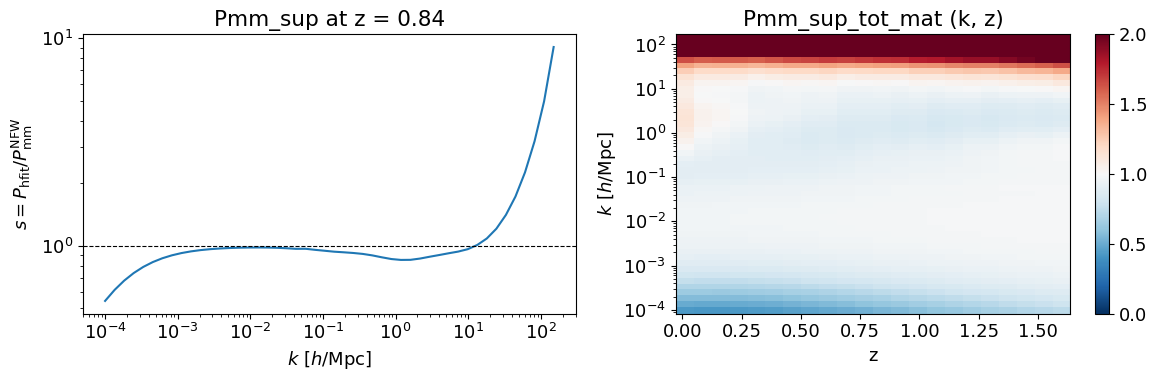

In [29]:
# Pmm_sup_tot_mat = phfit / Pmm_nfw_tot_mat  -- already computed by get_Pkzs
sup = np.array(cov_unfixed.Pmm_sup_tot_mat)   # shape: nk x nz

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
iz_mid = cov_unfixed.nz // 2

ax = axes[0]
ax.loglog(cov_unfixed.kPk_array, sup[:, iz_mid])
ax.axhline(1, ls='--', color='k', lw=0.8)
ax.set_xlabel(r'$k$ [$h$/Mpc]')
ax.set_ylabel(r'$s = P_{\rm hfit}/P_{\rm mm}^{\rm NFW}$')
ax.set_title(f'Pmm_sup at z = {float(cov_unfixed.z_array[iz_mid]):.2f}')

ax = axes[1]
km = ax.pcolormesh(cov_unfixed.z_array, cov_unfixed.kPk_array, sup,
                   vmin=0, vmax=2, cmap='RdBu_r')
ax.set_yscale('log')
ax.set_xlabel('z'); ax.set_ylabel(r'$k$ [$h$/Mpc]')
ax.set_title('Pmm_sup_tot_mat (k, z)')
plt.colorbar(km, ax=ax)
plt.tight_layout()

## §2 — 3-D Cauchy-Schwarz ratio $P_{ym}^2 / (P_{mm}\\,P_{yy})$

Should be $\\leq 1$ everywhere; values $> 1$ signal the inconsistency.

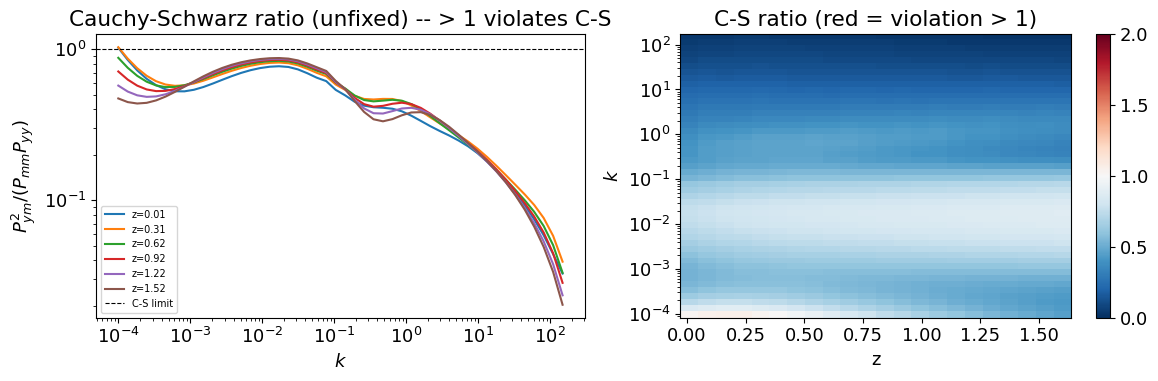

In [30]:
Pym = np.array(cov_unfixed.Pym_tot_mat)       # nk x nz
Pmm = np.array(cov_unfixed.Pmm_tot_mat)        # nk x nz (includes suppression)
Pyy = np.array(cov_unfixed.Pyy_tot_kz_mat)    # nk x nz (no suppression)

cs_ratio = Pym**2 / (Pmm * Pyy + 1e-300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for iz in range(0, cov_unfixed.nz, max(1, cov_unfixed.nz // 5)):
    ax.loglog(cov_unfixed.kPk_array, cs_ratio[:, iz],
              label=f'z={float(cov_unfixed.z_array[iz]):.2f}')
ax.axhline(1, ls='--', color='k', lw=0.8, label='C-S limit')
ax.set_xlabel(r'$k$'); ax.set_ylabel(r'$P_{ym}^2 / (P_{mm} P_{yy})$')
ax.set_title('Cauchy-Schwarz ratio (unfixed) -- > 1 violates C-S')
ax.legend(fontsize=7)

ax = axes[1]
km = ax.pcolormesh(cov_unfixed.z_array, cov_unfixed.kPk_array,
                   cs_ratio, vmin=0, vmax=2, cmap='RdBu_r')
ax.set_yscale('log')
ax.set_xlabel('z'); ax.set_ylabel(r'$k$')
ax.set_title('C-S ratio (red = violation > 1)')
plt.colorbar(km, ax=ax)
plt.tight_layout()

## §3 — Field-matrix PSD check (unfixed)

Build the $(N_{\\rm field} \\times N_{\\rm field})$ signal matrix at each $\\ell$ and check its minimum eigenvalue.

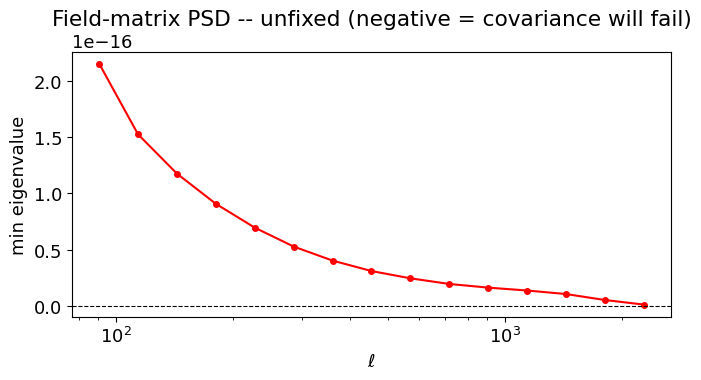

In [31]:
def check_full_field_psd_ky_gy(cov_obj):
    """Return min eigenvalue of the field signal matrix at each ell.
    Reads power spectra from cov_obj.Cl_result_dict.
    """
    ky_bins  = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]))
    gy_bins  = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]))
    Cyy      = np.array(cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"], float)
    nell     = len(Cyy)
    min_eigs = []
    for ell_idx in range(nell):
        nfield   = len(ky_bins) + len(gy_bins) + 1
        S        = np.zeros((nfield, nfield))
        offset_g = len(ky_bins)
        idx_y    = nfield - 1
        # kk block
        for a, sb1 in enumerate(ky_bins):
            for b, sb2 in enumerate(ky_bins):
                S[a, b] = cov_obj.Cl_result_dict["kk"][f"bin_{sb1}_{sb2}"]["tot_plus_noise_ellsurvey"][ell_idx]
        # gg block
        for a, lb1 in enumerate(gy_bins):
            for b, lb2 in enumerate(gy_bins):
                S[offset_g+a, offset_g+b] = cov_obj.Cl_result_dict["gg"][f"bin_{lb1}_{lb2}"]["tot_plus_noise_ellsurvey"][ell_idx]
        # gk block
        for a, sb in enumerate(ky_bins):
            for b, lb in enumerate(gy_bins):
                val = cov_obj.Cl_result_dict["gk"][f"bin_{lb}_{sb}"]["tot_ellsurvey"][ell_idx]
                S[a, offset_g+b] = val; S[offset_g+b, a] = val
        # ky
        for a, sb in enumerate(ky_bins):
            val = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]
            S[a, idx_y] = val; S[idx_y, a] = val
        # gy
        for b, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]
            S[offset_g+b, idx_y] = val; S[idx_y, offset_g+b] = val
        # yy
        S[idx_y, idx_y] = Cyy[ell_idx]
        ev = np.linalg.eigvalsh(0.5*(S + S.T))
        min_eigs.append(ev.min())
    return np.array(min_eigs)


def check_y_schur_ky_gy(cov_obj, ell_idx):
    """Schur complement C_yy - b^T A^+ b at a single ell.
    A = (kk, gg, gk) block; b = (ky, gy) cross-correlations with y.
    """
    ky_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]))
    gy_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]))
    nk, ng = len(ky_bins), len(gy_bins)
    off = nk; nkg = nk + ng
    A = np.zeros((nkg, nkg))
    b = np.zeros(nkg)
    for a, sb1 in enumerate(ky_bins):
        for c, sb2 in enumerate(ky_bins):
            A[a, c] = cov_obj.Cl_result_dict["kk"][f"bin_{sb1}_{sb2}"]["tot_plus_noise_ellsurvey"][ell_idx]
    for a, lb1 in enumerate(gy_bins):
        for c, lb2 in enumerate(gy_bins):
            A[off+a, off+c] = cov_obj.Cl_result_dict["gg"][f"bin_{lb1}_{lb2}"]["tot_plus_noise_ellsurvey"][ell_idx]
    for a, sb in enumerate(ky_bins):
        for c, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gk"][f"bin_{lb}_{sb}"]["tot_ellsurvey"][ell_idx]
            A[a, off+c] = val; A[off+c, a] = val
    for a, sb in enumerate(ky_bins):
        b[a] = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]
    for a, lb in enumerate(gy_bins):
        b[off+a] = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]
    Cyy   = float(cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"][ell_idx])
    schur = Cyy - float(b @ np.linalg.pinv(A) @ b)
    return schur, Cyy, Cyy - schur


min_eigs_unfixed = check_full_field_psd_ky_gy(cov_unfixed)
ell_survey = np.array(cov_unfixed.Cl_result_dict['l_array_survey'])

plt.figure(figsize=(7, 4))
plt.plot(ell_survey, min_eigs_unfixed, 'r-o', ms=4)
plt.axhline(0, ls='--', color='k', lw=0.8)
plt.xscale('log')
plt.xlabel(r'$\ell$'); plt.ylabel('min eigenvalue')
plt.title('Field-matrix PSD -- unfixed (negative = covariance will fail)')
plt.tight_layout()

## §4 — Schur complement profile (unfixed)

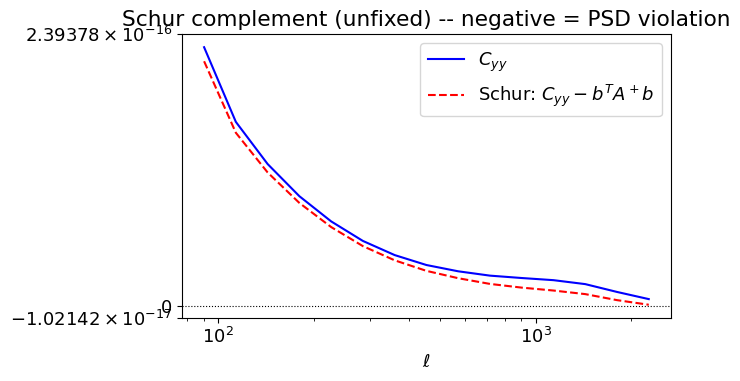

In [32]:
schur_vals = [check_y_schur_ky_gy(cov_unfixed, i)[0] for i in range(len(ell_survey))]
Cyy_vals   = [check_y_schur_ky_gy(cov_unfixed, i)[1] for i in range(len(ell_survey))]

plt.figure(figsize=(7, 4))
plt.plot(ell_survey, Cyy_vals,   'b-', label=r'$C_{yy}$')
plt.plot(ell_survey, schur_vals, 'r--', label=r'Schur: $C_{yy} - b^T A^+ b$')
plt.axhline(0, ls=':', color='k', lw=0.8)
plt.xscale('log'); plt.yscale('symlog', linthresh=1e-14)
plt.xlabel(r'$\ell$')
plt.title('Schur complement (unfixed) -- negative = PSD violation')
plt.legend(); plt.tight_layout()

## §5a — Fix A: patch Limber-projected matrices directly

**Why `get_Cl(Pkz_obj=modified_cov)` fails**: `cov_unfixed` is a `get_cov` object;  
copying it and passing as `Pkz_obj` carries covariance-specific attributes that confuse `get_Cl.__init__`.

**Revised approach**: work entirely at the Limber level, bypassing `get_Cl` re-run:
1. Evaluate `Pmm_sup_tot_mat` at the Limber wavenumber $k_\\ell(\\ell, z) = (\\ell+0.5)/\\chi(z)$  
   to get `sup_limber[nell, nz]`.
2. Multiply `Pkym_lz_mat`, `Pkgy_lz_mat`, `Pkyy_lz_mat` by `sup_limber`  
   (beam corrections are already absorbed, so this is exact under Limber).
3. Rebuild the 2D interpolators and `cached_power_spectra` slots [0,3], [3,0], [2,3], [3,2], [3,3].
4. Recompute `Cl_kappa_y_tot_mat`, `Cl_gal_y_tot_mat`, `Cl_y_y_signal_mat`, `Cl_y_y_tot_mat`.

In [43]:
from godmax.base_class import get_vmapped_func_warg

# BEFORE (failed: get_cov carries covariance-specific attrs that break get_Cl.__init__)
# Pkz_fixed = copy.copy(cov_unfixed)
# Pkz_fixed.Pym_tot_mat = cov_unfixed.Pym_tot_mat * cov_unfixed.Pmm_sup_tot_mat
# Pkz_fixed.Pgy_tot_mat = cov_unfixed.Pgy_tot_mat * cov_unfixed.Pmm_sup_tot_mat
# Cls_fixed = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
#                   Pkz_obj=Pkz_fixed)   # <-- ValueError in get_P_lz

# AFTER (Fix A: patch Limber-projected matrices directly on a copy of cov_unfixed)

# Step 1: evaluate Pmm_sup at Limber k values -> sup_limber[nell, nz]
k_np   = np.array(cov_unfixed.kPk_array)         # nk
chi_np = np.array(cov_unfixed.chi_array)          # nz
ell_np = np.array(cov_unfixed.ell_array)          # nell
sup_np = np.array(cov_unfixed.Pmm_sup_tot_mat)    # nk x nz

sup_limber = np.zeros((len(ell_np), len(chi_np)))
for jl, ell in enumerate(ell_np):
    for jz, chi in enumerate(chi_np):
        k_ell = (ell + 0.5) / max(float(chi), 1.0)
        sup_limber[jl, jz] = np.exp(
            np.interp(np.log(k_ell), np.log(k_np),
                      np.log(np.clip(sup_np[:, jz], 1e-30, None)))
        )
sup_limber_jax = jnp.array(sup_limber)   # nell x nz

# Step 2: copy cov_unfixed and apply sup_limber to the three affected Limber matrices
# Pkym_lz_mat = P_ym(k_ell, z) * Bl  -- beam already absorbed
# Pkgy_lz_mat = P_gy(k_ell, z) * Bl  -- beam already absorbed
# Pkyy_lz_mat = P_yy(k_ell, z) * Bl^2 -- beam already absorbed
Cls_fixed = copy.copy(cov_unfixed)
Cls_fixed.Pkym_lz_mat  = cov_unfixed.Pkym_lz_mat  * sup_limber_jax
Cls_fixed.Pkgy_lz_mat  = cov_unfixed.Pkgy_lz_mat  * sup_limber_jax
Cls_fixed.Pkyy_lz_mat  = cov_unfixed.Pkyy_lz_mat  * sup_limber_jax

# Step 3: rebuild 2D interpolators for ym, gy, yy
Cls_fixed.logPkymlz_2d_interp = interpax.Interpolator2D(
    jnp.log(Cls_fixed.ell_array), Cls_fixed.z_array,
    jnp.log(Cls_fixed.Pkym_lz_mat), extrap=True
)
Cls_fixed.logPkgylz_2d_interp = interpax.Interpolator2D(
    jnp.log(Cls_fixed.ell_array), Cls_fixed.z_array,
    jnp.log(Cls_fixed.Pkgy_lz_mat), extrap=True
)
Cls_fixed.logPkyylz_2d_interp = interpax.Interpolator2D(
    jnp.log(Cls_fixed.ell_array), Cls_fixed.z_array,
    jnp.log(Cls_fixed.Pkyy_lz_mat), extrap=True
)

# Step 4: rebuild cached_power_spectra (shape: 4 x 4 x nell x nz_for_Cls)
# slots: [0,3]=ym, [3,0]=ym, [2,3]=gy, [3,2]=gy, [3,3]=yy
log_ell = jnp.log(Cls_fixed.ell_array)
z_cls   = Cls_fixed.z_array_for_Cls

Cls_fixed.cached_power_spectra = Cls_fixed.cached_power_spectra.at[0, 3].set(
    vmap(lambda l: jnp.exp(Cls_fixed.logPkymlz_2d_interp(l, z_cls)))(log_ell)
)
Cls_fixed.cached_power_spectra = Cls_fixed.cached_power_spectra.at[3, 0].set(
    Cls_fixed.cached_power_spectra[0, 3]
)
Cls_fixed.cached_power_spectra = Cls_fixed.cached_power_spectra.at[2, 3].set(
    vmap(lambda l: jnp.exp(Cls_fixed.logPkgylz_2d_interp(l, z_cls)))(log_ell)
)
Cls_fixed.cached_power_spectra = Cls_fixed.cached_power_spectra.at[3, 2].set(
    Cls_fixed.cached_power_spectra[2, 3]
)
Cls_fixed.cached_power_spectra = Cls_fixed.cached_power_spectra.at[3, 3].set(
    vmap(lambda l: jnp.exp(Cls_fixed.logPkyylz_2d_interp(l, z_cls)))(log_ell)
)

# Step 5: recompute Cl arrays that feed Cl_result_dict in get_cov
vmapped_get_Cl = get_vmapped_func_warg(Cls_fixed.get_Cl_tot, 1, 4)
Cls_fixed.Cl_kappa_y_tot_mat = vmapped_get_Cl(jnp.arange(Cls_fixed.nbins),    0, 0, 3).T
Cls_fixed.Cl_gal_y_tot_mat   = vmapped_get_Cl(jnp.arange(Cls_fixed.nbins_lens), 0, 2, 3).T
Cls_fixed.Cl_y_y_signal_mat  = Cls_fixed.get_Cl_tot(0, 0, 3, 3)
Cls_fixed.Cl_y_y_tot_mat     = Cls_fixed.Cl_y_y_signal_mat + Cls_fixed.Cl_y_y_noise_mat

print('Cls_fixed shapes -- ky:', Cls_fixed.Cl_kappa_y_tot_mat.shape,
      '  gy:', Cls_fixed.Cl_gal_y_tot_mat.shape,
      '  yy:', Cls_fixed.Cl_y_y_tot_mat.shape)

Cls_fixed shapes -- ky: (15, 2)   gy: (15, 2)   yy: (15,)


## §5b — Fix B: swap C_kk kernel to NFW matter power

**Why Fix A alone is insufficient**: after applying `sup_limber` to `Pkym`, `Pkgy`, `Pkyy`,
the pointwise 3-D Cauchy-Schwarz condition for the `(kk, ky, yy)` block becomes

$$P_{ym}^2 \cdot s^2 \leq (P_{mm}^{dmb} \cdot s) \cdot (P_{yy} \cdot s)
\quad\Longleftrightarrow\quad
P_{ym}^2 \leq P_{mm}^{dmb} \cdot P_{yy}.$$

The halo model only guarantees $P_{ym}^2 \leq P_{mm}^{nfw} \cdot P_{yy}$.  
Since baryon feedback suppresses small-scale matter power,
$P_{mm}^{dmb} < P_{mm}^{nfw}$ at nonlinear scales → Fix A can still violate C-S.

**Fix B** (applied on top of Fix A): swap `cached_power_spectra[0, 0]`
(currently `P_mm_dmb * sup`) to slot `[1, 1]` = `P_mm_nfw` (= `phfit`,
the NFW halo-model matter power, already cached by `get_Cl.__init__`).
Then recompute `Cl_kappa_kappa_tot_mat`.

With this change the pointwise C-S becomes

$$P_{ym}^2 \cdot s \leq P_{mm}^{nfw} \cdot P_{yy},$$

which holds whenever $s \leq 1$ (true at nonlinear scales where baryon suppression
reduces power) because $P_{ym}^2 \leq P_{mm}^{nfw} \cdot P_{yy}$ by halo-model
construction.  At large scales $s \approx 1$, so C-S is satisfied exactly.

Only `Cl_kappa_kappa_tot_mat` needs recomputation — `Cl_gal_kappa_tot_mat` uses
`cached[2, 0]`, not `[0, 0]`, and is unaffected.


In [44]:
# Fix B: swap C_kk kernel from P_mm_dmb*sup to P_mm_nfw (slot [1,1])
# cached_power_spectra layout (from get_Cls.py):
#   [0, 0] = P_mm_dmb * sup  (baryonic + suppressed matter, used for C_kk)
#   [1, 1] = P_mm_nfw = phfit  (NFW halo-model matter, already computed)
#   [0, 3] = P_ym * sup_limber  (fixed by Fix A)
#   [3, 3] = P_yy * sup_limber  (fixed by Fix A)

Cls_fixed.cached_power_spectra = Cls_fixed.cached_power_spectra.at[0, 0].set(
    Cls_fixed.cached_power_spectra[1, 1]   # P_mm_nfw on (nell, nz_for_Cls)
)

# Recompute Cl_kappa_kappa_tot_mat (only probe that reads cached[0, 0])
vmapped_get_Cl_kk = get_vmapped_func_warg(Cls_fixed.get_Cl_tot, 2, 4)
Cls_fixed.Cl_kappa_kappa_tot_mat = vmapped_get_Cl_kk(
    jnp.arange(Cls_fixed.nbins), jnp.arange(Cls_fixed.nbins), 0, 0
).T

print('Cl_kappa_kappa_tot_mat shape:', Cls_fixed.Cl_kappa_kappa_tot_mat.shape)
print('Fix A+B applied to Cls_fixed.')


Cl_kappa_kappa_tot_mat shape: (15, 2, 2)
Fix A+B applied to Cls_fixed.


## §5c — Build fixed covariance


In [45]:
cov_fixed = get_cov(
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
    Cl_obj=Cls_fixed
)

## §6 — Verification: re-run diagnostics on fixed covariance

,min_eig_min,min_eig_max,schur_min,schur_max,any_eig_negative,any_schur_negative
version,,,,,,
unfixed,1.130866e-18,2.156475e-16,1.130866e-18,2.156475e-16,False,False
fixed,1.627464e-18,2.157750e-16,1.627464e-18,2.157750e-16,False,False


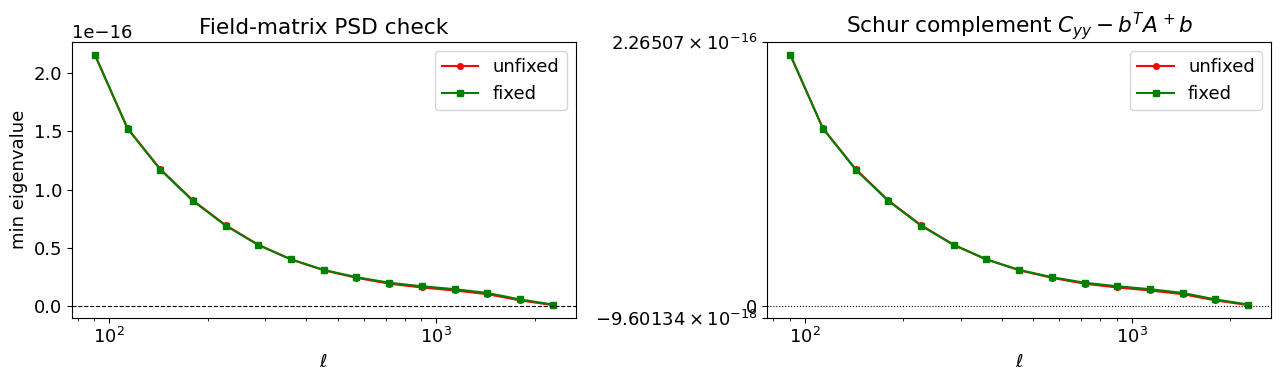

In [46]:
min_eigs_fixed = check_full_field_psd_ky_gy(cov_fixed)
schur_fixed    = [check_y_schur_ky_gy(cov_fixed, i)[0] for i in range(len(ell_survey))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(ell_survey, min_eigs_unfixed, 'r-o', ms=4, label='unfixed')
ax.plot(ell_survey, min_eigs_fixed,   'g-s', ms=4, label='fixed')
ax.axhline(0, ls='--', color='k', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel(r'$\ell$'); ax.set_ylabel('min eigenvalue')
ax.set_title('Field-matrix PSD check')
ax.legend()

ax = axes[1]
ax.plot(ell_survey, schur_vals,  'r-o', ms=4, label='unfixed')
ax.plot(ell_survey, schur_fixed, 'g-s', ms=4, label='fixed')
ax.axhline(0, ls=':', color='k', lw=0.8)
ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=1e-14)
ax.set_xlabel(r'$\ell$')
ax.set_title('Schur complement $C_{yy} - b^T A^+ b$')
ax.legend()
plt.tight_layout()

# Summary table
rows = []
for label, me, sc in [('unfixed', min_eigs_unfixed, schur_vals),
                       ('fixed',   min_eigs_fixed,   schur_fixed)]:
    rows.append({
        'version':            label,
        'min_eig_min':        float(np.min(me)),
        'min_eig_max':        float(np.max(me)),
        'schur_min':          float(np.min(sc)),
        'schur_max':          float(np.max(sc)),
        'any_eig_negative':   bool(np.any(np.array(me) < 0)),
        'any_schur_negative': bool(np.any(np.array(sc) < 0)),
    })
df = pd.DataFrame(rows).set_index('version')
display(df)

## §7 — Normalised Cauchy-Schwarz ratios

A small absolute eigenvalue does **not** imply the matrix is PSD:
if the Cls themselves are beam-suppressed to near-zero, the ratio
$r_{xy} = C_{xy}^2 / (C_{xx}\,C_{yy})$ can still approach 1
(or exceed 1) even though all values are tiny.
This section plots $r_{xy}(\ell)$ for all cross-pairs involving $y$
and the galaxy–kappa pair, alongside the raw Cls,
to determine whether the worst-ell minimum eigenvalue reflects
a genuine C-S near-violation or pure floating-point noise.


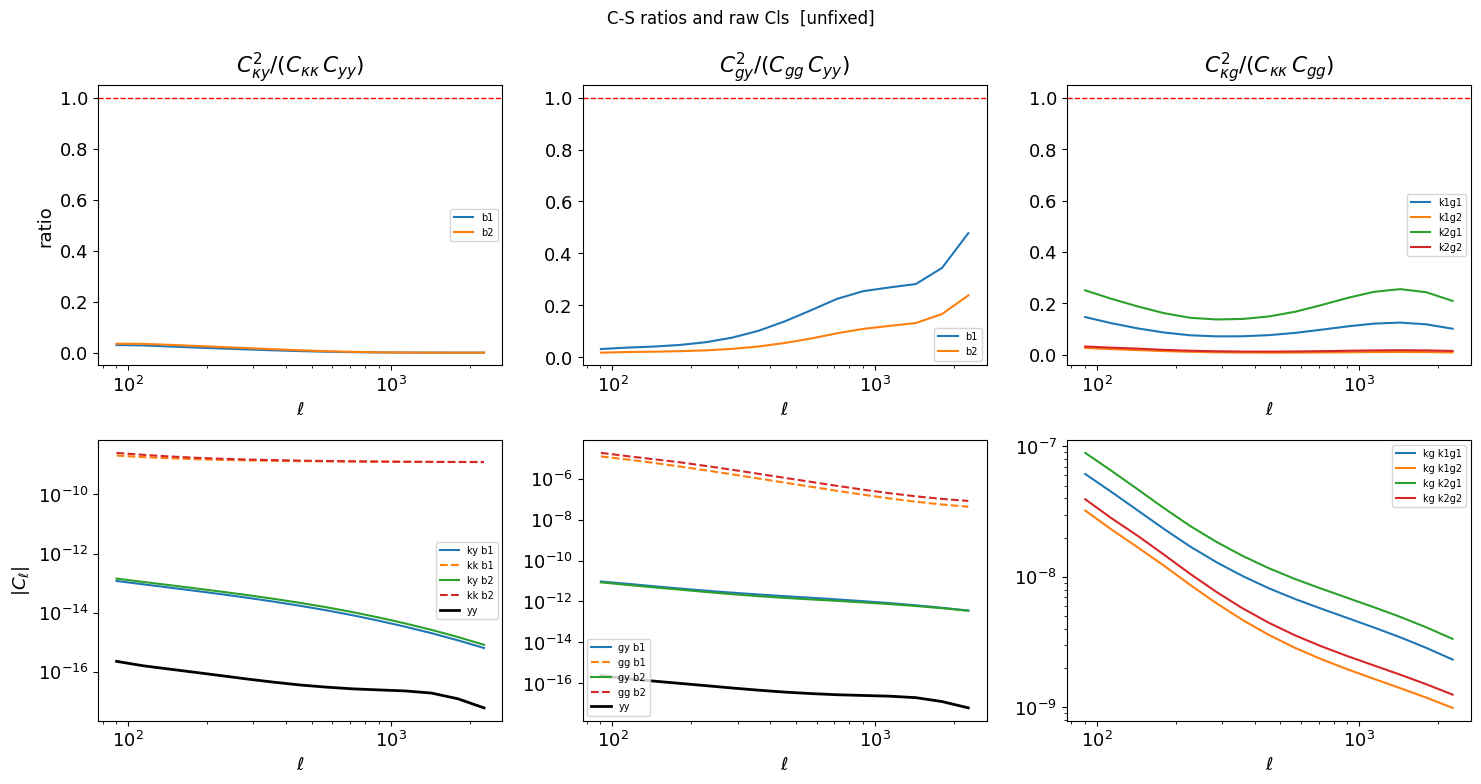


unfixed — max C-S ratios (>1 = genuine violation):
  ky b1: max r = 0.0299  at ell = 90.4
  ky b2: max r = 0.0350  at ell = 90.4
  gy b1: max r = 0.4776  at ell = 2269.7
  gy b2: max r = 0.2379  at ell = 2269.7
  kg k1g1: max r = 0.1470  at ell = 90.4
  kg k1g2: max r = 0.0271  at ell = 90.4
  kg k2g1: max r = 0.2555  at ell = 1432.1
  kg k2g2: max r = 0.0327  at ell = 90.4


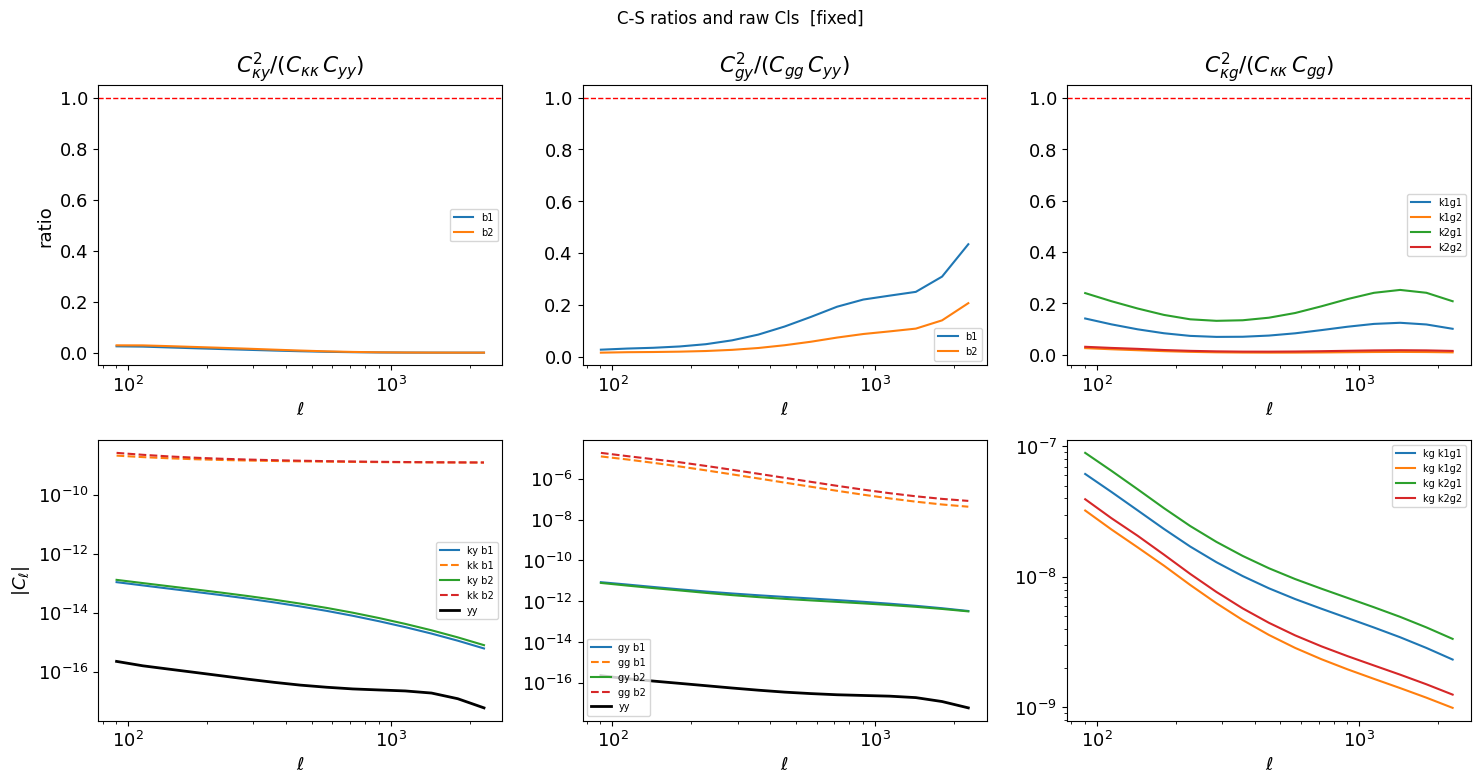


fixed — max C-S ratios (>1 = genuine violation):
  ky b1: max r = 0.0249  at ell = 90.4
  ky b2: max r = 0.0288  at ell = 90.4
  gy b1: max r = 0.4337  at ell = 2269.7
  gy b2: max r = 0.2061  at ell = 2269.7
  kg k1g1: max r = 0.1413  at ell = 90.4
  kg k1g2: max r = 0.0260  at ell = 90.4
  kg k2g1: max r = 0.2524  at ell = 1432.1
  kg k2g2: max r = 0.0313  at ell = 90.4


In [51]:
def cs_ratios_ygk(cov_obj, label=''):
    """
    Compute and plot normalised C-S ratios r_xy = C_xy^2 / (C_xx * C_yy)
    for ky, gy, and kg pairs, per tomographic bin.
    Also plots the raw Cl amplitudes on a companion panel.

    Values of r_xy > 1 signal a genuine C-S violation independent of
    the absolute scale of the Cls.
    """
    rd = cov_obj.Cl_result_dict
    ell = np.array(rd['l_array_survey'], float)

    ky_bins = sorted(set(bc[0] for bc in rd['ky']['bin_combs']))
    gy_bins = sorted(set(bc[0] for bc in rd['gy']['bin_combs']))

    Cyy = np.array(rd['yy']['bin_0_0']['tot_plus_noise_ellsurvey'], float)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'C-S ratios and raw Cls  [{label}]', fontsize=12)

    ax_ky_r, ax_gy_r, ax_kg_r = axes[0]
    ax_ky_c, ax_gy_c, ax_kg_c = axes[1]

    # ── ky ──────────────────────────────────────────────────────────────
    for sb in ky_bins:
        Cky = np.array(rd['ky'][f'bin_{sb}_0']['tot_plus_noise_ellsurvey'], float)
        Ckk = np.array(rd['kk'][f'bin_{sb}_{sb}']['tot_plus_noise_ellsurvey'], float)
        r   = Cky**2 / np.clip(Ckk * Cyy, 1e-300, None)
        ax_ky_r.plot(ell, r,  label=f'b{sb}')
        ax_ky_c.plot(ell, np.abs(Cky), ls='-',  label=f'ky b{sb}')
        ax_ky_c.plot(ell, Ckk,          ls='--', label=f'kk b{sb}')
    ax_ky_c.plot(ell, Cyy, 'k-', lw=2, label='yy')

    ax_ky_r.axhline(1, ls='--', color='r', lw=1)
    ax_ky_r.set_title(r'$C_{\kappa y}^2 / (C_{\kappa\kappa}\,C_{yy})$')
    ax_ky_r.set_xscale('log'); ax_ky_r.set_xlabel(r'$\ell$')
    ax_ky_r.set_ylabel('ratio'); ax_ky_r.legend(fontsize=7)
    ax_ky_c.set_xscale('log'); ax_ky_c.set_yscale('log')
    ax_ky_c.set_xlabel(r'$\ell$'); ax_ky_c.set_ylabel(r'$|C_\ell|$')
    ax_ky_c.legend(fontsize=7)

    # ── gy ──────────────────────────────────────────────────────────────
    for lb in gy_bins:
        Cgy = np.array(rd['gy'][f'bin_{lb}_0']['tot_plus_noise_ellsurvey'], float)
        Cgg = np.array(rd['gg'][f'bin_{lb}_{lb}']['tot_plus_noise_ellsurvey'], float)
        r   = Cgy**2 / np.clip(Cgg * Cyy, 1e-300, None)
        ax_gy_r.plot(ell, r,  label=f'b{lb}')
        ax_gy_c.plot(ell, np.abs(Cgy), ls='-',  label=f'gy b{lb}')
        ax_gy_c.plot(ell, Cgg,          ls='--', label=f'gg b{lb}')
    ax_gy_c.plot(ell, Cyy, 'k-', lw=2, label='yy')

    ax_gy_r.axhline(1, ls='--', color='r', lw=1)
    ax_gy_r.set_title(r'$C_{gy}^2 / (C_{gg}\,C_{yy})$')
    ax_gy_r.set_xscale('log'); ax_gy_r.set_xlabel(r'$\ell$')
    ax_gy_r.legend(fontsize=7)
    ax_gy_c.set_xscale('log'); ax_gy_c.set_yscale('log')
    ax_gy_c.set_xlabel(r'$\ell$'); ax_gy_c.legend(fontsize=7)

    # ── kg ──────────────────────────────────────────────────────────────
    for sb in ky_bins:
        for lb in gy_bins:
            Ckg = np.array(rd['gk'][f'bin_{lb}_{sb}']['tot_ellsurvey'], float)
            Ckk = np.array(rd['kk'][f'bin_{sb}_{sb}']['tot_plus_noise_ellsurvey'], float)
            Cgg = np.array(rd['gg'][f'bin_{lb}_{lb}']['tot_plus_noise_ellsurvey'], float)
            r   = Ckg**2 / np.clip(Ckk * Cgg, 1e-300, None)
            ax_kg_r.plot(ell, r,  label=f'k{sb}g{lb}')
            ax_kg_c.plot(ell, np.abs(Ckg), ls='-',  label=f'kg k{sb}g{lb}')

    ax_kg_r.axhline(1, ls='--', color='r', lw=1)
    ax_kg_r.set_title(r'$C_{\kappa g}^2 / (C_{\kappa\kappa}\,C_{gg})$')
    ax_kg_r.set_xscale('log'); ax_kg_r.set_xlabel(r'$\ell$')
    ax_kg_r.legend(fontsize=7)
    ax_kg_c.set_xscale('log'); ax_kg_c.set_yscale('log')
    ax_kg_c.set_xlabel(r'$\ell$'); ax_kg_c.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── worst-ell summary ───────────────────────────────────────────────
    print(f'\n{label} — max C-S ratios (>1 = genuine violation):')
    for sb in ky_bins:
        Cky = np.array(rd['ky'][f'bin_{sb}_0']['tot_plus_noise_ellsurvey'], float)
        Ckk = np.array(rd['kk'][f'bin_{sb}_{sb}']['tot_plus_noise_ellsurvey'], float)
        r   = Cky**2 / np.clip(Ckk * Cyy, 1e-300, None)
        imax = np.argmax(r)
        print(f'  ky b{sb}: max r = {r[imax]:.4f}  at ell = {ell[imax]:.1f}')
    for lb in gy_bins:
        Cgy = np.array(rd['gy'][f'bin_{lb}_0']['tot_plus_noise_ellsurvey'], float)
        Cgg = np.array(rd['gg'][f'bin_{lb}_{lb}']['tot_plus_noise_ellsurvey'], float)
        r   = Cgy**2 / np.clip(Cgg * Cyy, 1e-300, None)
        imax = np.argmax(r)
        print(f'  gy b{lb}: max r = {r[imax]:.4f}  at ell = {ell[imax]:.1f}')
    for sb in ky_bins:
        for lb in gy_bins:
            Ckg = np.array(rd['gk'][f'bin_{lb}_{sb}']['tot_ellsurvey'], float)
            Ckk = np.array(rd['kk'][f'bin_{sb}_{sb}']['tot_plus_noise_ellsurvey'], float)
            Cgg = np.array(rd['gg'][f'bin_{lb}_{lb}']['tot_plus_noise_ellsurvey'], float)
            r   = Ckg**2 / np.clip(Ckk * Cgg, 1e-300, None)
            imax = np.argmax(r)
            print(f'  kg k{sb}g{lb}: max r = {r[imax]:.4f}  at ell = {ell[imax]:.1f}')


cs_ratios_ygk(cov_unfixed, label='unfixed')
cs_ratios_ygk(cov_fixed,   label='fixed')


In [52]:
def check_full_field_psd_ky_gy(cov_obj):
    ky_bins = [bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]]   # source bins, 1-based
    gy_bins = [bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]]   # lens bins, 1-based

    ky_bins = sorted(set(ky_bins))
    gy_bins = sorted(set(gy_bins))

    Cyy = np.array(cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"], float)
    nell = len(Cyy)

    min_eigs = []

    for ell_idx in range(nell):
        nfield = len(ky_bins) + len(gy_bins) + 1
        S = np.zeros((nfield, nfield), dtype=float)

        # k-k block
        for a, sb1 in enumerate(ky_bins):
            for b, sb2 in enumerate(ky_bins):
                key = f"bin_{sb1}_{sb2}"
                S[a, b] = cov_obj.Cl_result_dict["kk"][key]["tot_plus_noise_ellsurvey"][ell_idx]

        # g-g block
        offset_g = len(ky_bins)
        for a, lb1 in enumerate(gy_bins):
            for b, lb2 in enumerate(gy_bins):
                key = f"bin_{lb1}_{lb2}"
                S[offset_g + a, offset_g + b] = cov_obj.Cl_result_dict["gg"][key]["tot_plus_noise_ellsurvey"][ell_idx]

        # k-g block from gk
        for a, sb in enumerate(ky_bins):
            for b, lb in enumerate(gy_bins):
                key = f"bin_{lb}_{sb}"
                val = cov_obj.Cl_result_dict["gk"][key]["tot_ellsurvey"][ell_idx]
                S[a, offset_g + b] = val
                S[offset_g + b, a] = val

        # k-y block
        idx_y = nfield - 1
        for a, sb in enumerate(ky_bins):
            val = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]
            S[a, idx_y] = val
            S[idx_y, a] = val

        # g-y block
        for b, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]
            S[offset_g + b, idx_y] = val
            S[idx_y, offset_g + b] = val

        # y-y
        S[idx_y, idx_y] = Cyy[ell_idx]

        ev = np.linalg.eigvalsh(0.5 * (S + S.T))
        min_eigs.append(ev.min())

    return np.array(min_eigs)

min_eigs_full = check_full_field_psd_ky_gy(cov_fixed)
print(min_eigs_full.min())

min_eigs_full = check_full_field_psd_ky_gy(cov_fixed)
worst_ell_idx = np.argmin(min_eigs_full)
print("worst ell index =", worst_ell_idx)
print("min eigenvalue  =", min_eigs_full[worst_ell_idx])
print("ell value       =", cov_fixed.Cl_result_dict["l_array_survey"][worst_ell_idx])

def get_full_field_matrix_ky_gy(cov_obj, ell_idx):
    ky_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]))
    gy_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]))

    Cyy = np.array(cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"], float)

    nfield = len(ky_bins) + len(gy_bins) + 1
    S = np.zeros((nfield, nfield), dtype=float)
    labels = []

    for sb in ky_bins:
        labels.append(f"k{sb}")
    for lb in gy_bins:
        labels.append(f"g{lb}")
    labels.append("y")

    # kk
    for a, sb1 in enumerate(ky_bins):
        for b, sb2 in enumerate(ky_bins):
            S[a, b] = cov_obj.Cl_result_dict["kk"][f"bin_{sb1}_{sb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gg
    off = len(ky_bins)
    for a, lb1 in enumerate(gy_bins):
        for b, lb2 in enumerate(gy_bins):
            S[off+a, off+b] = cov_obj.Cl_result_dict["gg"][f"bin_{lb1}_{lb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gk
    for a, sb in enumerate(ky_bins):
        for b, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gk"][f"bin_{lb}_{sb}"]["tot_ellsurvey"][ell_idx]
            S[a, off+b] = val
            S[off+b, a] = val

    # ky
    iy = nfield - 1
    for a, sb in enumerate(ky_bins):
        val = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]
        S[a, iy] = val
        S[iy, a] = val

    # gy
    for b, lb in enumerate(gy_bins):
        val = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]
        S[off+b, iy] = val
        S[iy, off+b] = val

    # yy
    S[iy, iy] = Cyy[ell_idx]

    return 0.5*(S+S.T), labels

S, labels = get_full_field_matrix_ky_gy(cov_fixed, worst_ell_idx)
evals, evecs = np.linalg.eigh(S)
print("min eval:", evals[0])
for lab, coeff in zip(labels, evecs[:, 0]):
    print(f"{lab:>4s}  {coeff:+.4e}")

def check_y_schur_ky_gy(cov_obj, ell_idx):
    ky_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]))
    gy_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]))

    nk = len(ky_bins)
    ng = len(gy_bins)
    nkg = nk + ng

    A = np.zeros((nkg, nkg), dtype=float)
    b = np.zeros(nkg, dtype=float)

    # kk block
    for a, sb1 in enumerate(ky_bins):
        for c, sb2 in enumerate(ky_bins):
            A[a, c] = cov_obj.Cl_result_dict["kk"][f"bin_{sb1}_{sb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gg block
    off = nk
    for a, lb1 in enumerate(gy_bins):
        for c, lb2 in enumerate(gy_bins):
            A[off+a, off+c] = cov_obj.Cl_result_dict["gg"][f"bin_{lb1}_{lb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gk block
    for a, sb in enumerate(ky_bins):
        for c, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gk"][f"bin_{lb}_{sb}"]["tot_ellsurvey"][ell_idx]
            A[a, off+c] = val
            A[off+c, a] = val

    # ky entries
    for a, sb in enumerate(ky_bins):
        b[a] = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]

    # gy entries
    for c, lb in enumerate(gy_bins):
        b[off+c] = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]

    Cyy = cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"][ell_idx]

    schur = Cyy - b @ np.linalg.pinv(A) @ b
    return schur, Cyy, b, A

schur, Cyy, b, A = check_y_schur_ky_gy(cov_fixed, 154)
print("Schur complement =", schur)
print("Cyy =", Cyy)
print("b^T A^+ b =", Cyy - schur)


1.6274635301779665e-18
worst ell index = 14
min eigenvalue  = 1.6274635301779665e-18
ell value       = 2269.665659819005
min eval: 1.6274635301779696e-18
  k1  +2.0814e-05
  k2  +2.9705e-05
  g1  -1.0351e-05
  g2  -2.9757e-06
   y  +1.0000e+00
Schur complement = 1.6274635325078741e-18
Cyy = 6.003147431067825e-18
b^T A^+ b = 4.375683898559951e-18


In [53]:

# ─────────────────────────────────────────────────────────────────────────────
# Labels for block plots
# ─────────────────────────────────────────────────────────────────────────────
def format_block_label(probe, bins):
    b1, b2 = bins

    if probe == "yy":
        return "yy"
    if probe in ["ky", "gy"]:
        return f"{probe}[{b1}]"
    if probe in ["kk", "gg", "gk"]:
        return f"{probe}[{b1},{b2}]"
    return f"{probe}{bins}"


def decorate_block_matrix(ax, bin_comb_all, nell, fontsize=7, rotate_labels=True):
    nblocks = len(bin_comb_all)
    nell_all = nblocks * nell

    for k in range(1, nblocks):
        pos = k * nell - 0.5
        ax.axhline(pos, color="white", lw=0.5, alpha=0.7)
        ax.axvline(pos, color="white", lw=0.5, alpha=0.7)

    centers = np.arange(nblocks) * nell + 0.5 * (nell - 1)
    labels = [format_block_label(probe, bins) for probe, bins in bin_comb_all]

    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels, rotation=90 if rotate_labels else 0, fontsize=fontsize)
    ax.set_yticklabels(labels, fontsize=fontsize)

    ax.set_xlim(-0.5, nell_all - 0.5)
    ax.set_ylim(-0.5, nell_all - 0.5)


# ─────────────────────────────────────────────────────────────────────────────
# Build ordering DIRECTLY from cov_obj.Cl_result_dict
# ─────────────────────────────────────────────────────────────────────────────
def build_bin_comb_all_from_cov(cov_obj, probes_analysis):
    """
    Use the exact bin ordering stored inside cov_obj.Cl_result_dict,
    but drop redundant lower-triangle entries for symmetric auto-spectra
    like kk and gg.
    """
    bin_comb_all = []

    for probe in probes_analysis:
        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in cov_obj.Cl_result_dict")

        if "bin_combs" not in cov_obj.Cl_result_dict[probe]:
            raise KeyError(f"Probe '{probe}' missing 'bin_combs' in cov_obj.Cl_result_dict")

        raw_bin_combs = cov_obj.Cl_result_dict[probe]["bin_combs"]

        if probe in ["kk", "gg"]:
            raw_bin_combs = [bc for bc in raw_bin_combs if bc[0] <= bc[1]]

        for b1, b2 in raw_bin_combs:
            bin_comb_all.append((probe, (b1, b2)))

    return bin_comb_all


# ─────────────────────────────────────────────────────────────────────────────
# Build theory/data vector from SAME ordering
# ─────────────────────────────────────────────────────────────────────────────
def build_data_vector_from_cov(bin_comb_all, cov_obj, nell, use_noise=False):
    """
    Build the data vector using the same ordering as bin_comb_all.

    Parameters
    ----------
    bin_comb_all : list
        List of (probe, (b1,b2)) tuples.
    cov_obj : object
        Must contain Cl_result_dict.
    nell : int
        Number of ell bins.
    use_noise : bool, optional
        If True, use 'tot_plus_noise_ellsurvey' when available.
        Otherwise use 'tot_ellsurvey'.

    Returns
    -------
    data_vec : ndarray
        Flattened data vector.
    """
    data_vec = np.zeros(len(bin_comb_all) * nell, dtype=float)

    for i, (probe, (b1, b2)) in enumerate(bin_comb_all):
        sl = slice(i * nell, (i + 1) * nell)
        bin_key = f"bin_{b1}_{b2}"

        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in Cl_result_dict")

        if bin_key not in cov_obj.Cl_result_dict[probe]:
            raise KeyError(f"Missing {probe}[{bin_key}] in Cl_result_dict")

        entry = cov_obj.Cl_result_dict[probe][bin_key]

        if use_noise and "tot_plus_noise_ellsurvey" in entry:
            arr = entry["tot_plus_noise_ellsurvey"]
        else:
            arr = entry["tot_ellsurvey"]

        arr = np.array(arr, dtype=float)

        if arr.shape[0] != nell:
            raise ValueError(
                f"Data vector block {probe}[{bin_key}] has length {arr.shape[0]}, expected {nell}"
            )

        data_vec[sl] = arr

    return data_vec


# ─────────────────────────────────────────────────────────────────────────────
# Full covariance assembly
# ─────────────────────────────────────────────────────────────────────────────
def full_cov_matrix_from_covobj(cov_obj, bin_comb_all, nell, verbose=False, enforce_symmetry=False):
    """
    Assemble the full covariance matrix from cov_obj.covtot_dict using the exact
    bin ordering in bin_comb_all.

    Important:
    - If the reversed probe pair is used, the block is transposed explicitly.
    """
    nblocks = len(bin_comb_all)
    nell_all = nblocks * nell
    cov_all = np.zeros((nell_all, nell_all), dtype=float)

    for i, (probe1, (b1, b2)) in enumerate(bin_comb_all):
        for j, (probe2, (b3, b4)) in enumerate(bin_comb_all):
            dict_key = f"{probe1}_{probe2}"
            rev_dict_key = f"{probe2}_{probe1}"

            key = f"bin_{b1}_{b2}_{b3}_{b4}"
            key_sym = f"bin_{b3}_{b4}_{b1}_{b2}"

            if dict_key in cov_obj.covG_dict and key in cov_obj.covG_dict[dict_key]:
                block = np.array(cov_obj.covG_dict[dict_key][key], dtype=float)
                path = "direct"

            elif rev_dict_key in cov_obj.covG_dict and key_sym in cov_obj.covG_dict[rev_dict_key]:
                block = np.array(cov_obj.covG_dict[rev_dict_key][key_sym], dtype=float).T
                path = "transposed"

            else:
                raise KeyError(
                    f"Missing covariance block.\n"
                    f"  Tried: {dict_key}[{key}]\n"
                    f"  Tried: {rev_dict_key}[{key_sym}] (then transpose)"
                )

            if block.shape != (nell, nell):
                raise ValueError(
                    f"Block for [{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"has shape {block.shape}, expected ({nell}, {nell})."
                )

            row = slice(i * nell, (i + 1) * nell)
            col = slice(j * nell, (j + 1) * nell)
            cov_all[row, col] = block

            if verbose:
                print(
                    f"[{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"path={path}, shape={block.shape}, "
                    f"min={block.min():.3e}, max={block.max():.3e}"
                )

    if enforce_symmetry:
        cov_all = 0.5 * (cov_all + cov_all.T)

    return cov_all


# ─────────────────────────────────────────────────────────────────────────────
# Main analysis function
# ─────────────────────────────────────────────────────────────────────────────
def analyze_covariance(
    probes_analysis,
    cov_obj,
    analysis_dict,
    results_path,
    verbose_cov=False,
    enforce_symmetry=False,
    show_plots=True,
    add_block_guides=True,
    use_noise_in_datavector=False,
):
    """
    Build theory vector + full covariance for a chosen set of probes,
    using cov_obj.Cl_result_dict['bin_combs'] as the single source of truth
    for probe/bin ordering.
    """
    os.makedirs(results_path, exist_ok=True)
    probe_tag = "_".join(probes_analysis)
    nell = len(analysis_dict["l_array_survey"])

    print(f"\n{'=' * 72}")
    print(f"Probes: {probes_analysis}   [{probe_tag}]")

    for probe in probes_analysis:
        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in cov_obj.Cl_result_dict")

        print(f"  {probe} bin_combs: {cov_obj.Cl_result_dict[probe]['bin_combs']}")

    bin_comb_all = build_bin_comb_all_from_cov(cov_obj, probes_analysis)
    nell_all = len(bin_comb_all) * nell

    print("\n  Full ordering:")
    for idx, item in enumerate(bin_comb_all):
        print(f"    {idx:02d}: {item}")

    data_vec = build_data_vector_from_cov(
        bin_comb_all=bin_comb_all,
        cov_obj=cov_obj,
        nell=nell,
        use_noise=use_noise_in_datavector,
    )

    cov_total = full_cov_matrix_from_covobj(
        cov_obj=cov_obj,
        bin_comb_all=bin_comb_all,
        nell=nell,
        verbose=verbose_cov,
        enforce_symmetry=enforce_symmetry,
    )

    max_asymm = np.max(np.abs(cov_total - cov_total.T))
    diag = np.diag(cov_total)
    min_diag = diag.min()
    max_diag = diag.max()
    has_nan = np.isnan(cov_total).any()
    has_inf = np.isinf(cov_total).any()

    cov_sym = 0.5 * (cov_total + cov_total.T)
    eigvals = np.linalg.eigvalsh(cov_sym)
    eig_min = eigvals.min()
    eig_max = eigvals.max()
    n_neg = np.sum(eigvals < 0)

    try:
        cond = np.linalg.cond(cov_total)
    except np.linalg.LinAlgError:
        cond = np.inf

    try:
        sign_det, logdet = np.linalg.slogdet(cov_total)
    except np.linalg.LinAlgError:
        sign_det, logdet = np.nan, np.nan

    print(f"\n  Matrix size : {cov_total.shape}")
    print(f"  Max asymm.  : {max_asymm:.3e}")
    print(f"  Min diag    : {min_diag:.3e}")
    print(f"  Max diag    : {max_diag:.3e}")
    print(f"  Eigen min   : {eig_min:.3e}")
    print(f"  Eigen max   : {eig_max:.3e}")
    print(f"  Neg eigvals : {n_neg} / {len(eigvals)}")
    print(f"  Condition # : {cond:.3e}")
    print(f"  log|det|    : {logdet:.3f}  (sign = {int(sign_det) if np.isfinite(sign_det) else sign_det})")
    print(f"  NaN / Inf   : {has_nan} / {has_inf}")
    print(f"{'=' * 72}")

    sigma = np.sqrt(np.abs(diag))
    sigma[sigma == 0] = 1.0
    corr = cov_total / np.outer(sigma, sigma)

    stats_text = (
        f"probes: {probe_tag}\n"
        f"size: {cov_total.shape[0]}×{cov_total.shape[1]}\n"
        f"max asymm = {max_asymm:.2e}\n"
        f"min diag = {min_diag:.2e}\n"
        f"$\\lambda_{{\\min}}$ = {eig_min:.2e}\n"
        f"$\\lambda_{{\\max}}$ = {eig_max:.2e}\n"
        f"cond = {cond:.2e}\n"
        f"$\\log|\\det|$ = {logdet:.2f}\n"
        f"sign(det) = {int(sign_det) if np.isfinite(sign_det) else sign_det}\n"
        f"neg. eigvals = {n_neg}"
    )

    cmap_cov = plt.cm.viridis.copy()
    cmap_cov.set_bad("lightgray")

    cmap_corr = plt.cm.RdBu_r.copy()
    cmap_corr.set_bad("lightgray")

    log_cov = np.log10(np.abs(cov_total))
    log_cov[np.isinf(log_cov)] = np.nan

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im0 = axes[0].imshow(
        log_cov,
        origin="lower",
        aspect="auto",
        cmap=cmap_cov,
        vmin=np.nanpercentile(log_cov, 2),
        vmax=np.nanpercentile(log_cov, 98),
    )
    cb0 = plt.colorbar(im0, ax=axes[0], label=r"$\log_{10}|\mathrm{Cov}|$", fraction=0.046)
    cb0.ax.tick_params(labelsize=9)
    axes[0].set_facecolor("gray")
    axes[0].set_title(f"Covariance (log$_{{10}}$) — {probe_tag}", fontsize=11)

    im1 = axes[1].imshow(
        corr,
        origin="lower",
        aspect="auto",
        cmap=cmap_corr,
        vmin=-1,
        vmax=1,
    )
    cb1 = plt.colorbar(im1, ax=axes[1], label="Correlation", fraction=0.046)
    cb1.set_ticks(np.linspace(-1, 1, 5))
    cb1.ax.tick_params(labelsize=9)
    axes[1].set_facecolor("gray")
    axes[1].set_title(f"Correlation matrix — {probe_tag}", fontsize=11)

    if add_block_guides:
        decorate_block_matrix(axes[0], bin_comb_all, nell, fontsize=7)
        decorate_block_matrix(axes[1], bin_comb_all, nell, fontsize=7)

    fig.text(
        0.01,
        0.5,
        stats_text,
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="wheat", alpha=0.6),
        transform=fig.transFigure,
    )

    plt.tight_layout(rect=[0.13, 0, 1, 1])

    fname = os.path.join(results_path, f"cov_corr_{probe_tag}.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    print(f"Saved: {fname}")

    return {
        "bin_comb_all": bin_comb_all,
        "nell": nell,
        "nell_all": nell_all,
        "data_vec": data_vec,
        "cov_total": cov_total,
        "corr": corr,
        "eigvals": eigvals,
        "cond": cond,
        "sign_det": sign_det,
        "logdet": logdet,
        "max_asymm": max_asymm,
        "min_diag": min_diag,
        "max_diag": max_diag,
        "n_neg": n_neg,
    }




Probes: ['gk', 'gg']   [gk_gg]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gk', (1, 1))
    01: ('gk', (1, 2))
    02: ('gk', (2, 1))
    03: ('gk', (2, 2))
    04: ('gg', (1, 1))
    05: ('gg', (1, 2))
    06: ('gg', (2, 2))

  Matrix size : (105, 105)
  Max asymm.  : 0.000e+00
  Min diag    : 7.123e-23
  Max diag    : 4.611e-13
  Eigen min   : 4.120e-23
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 105
  Condition # : 1.498e+10
  log|det|    : -4418.479  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


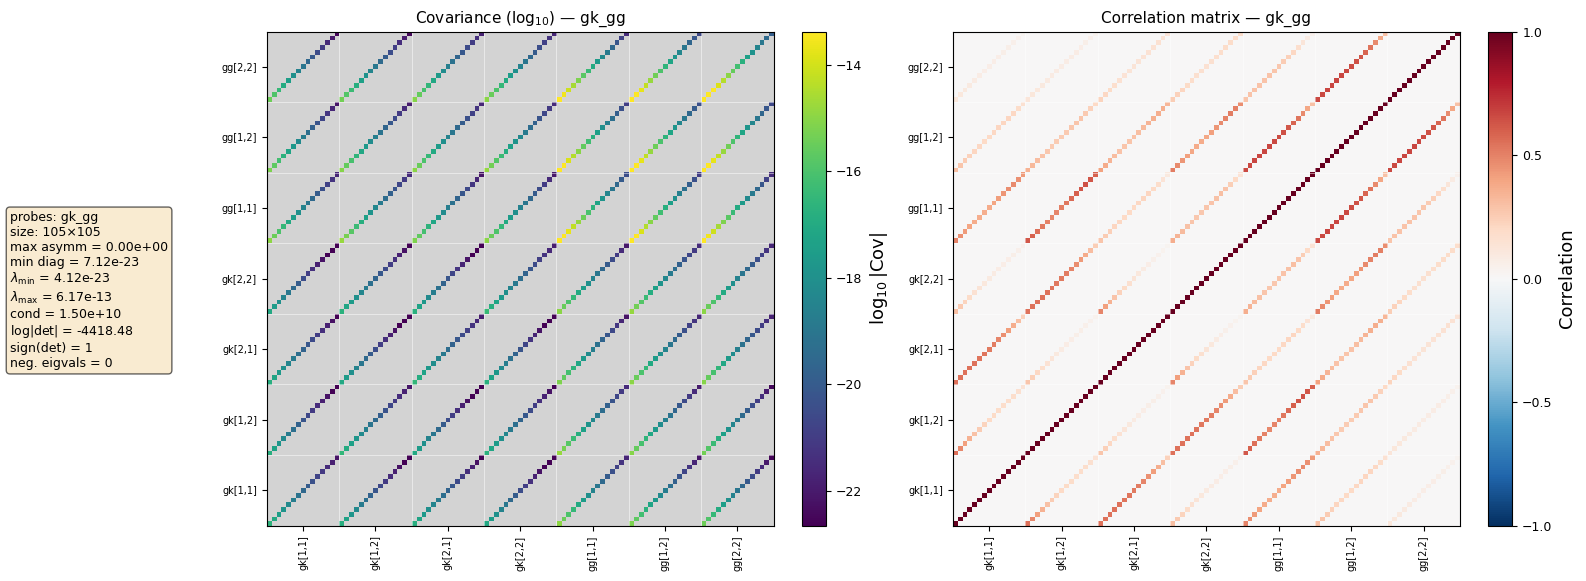

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gk_gg.png

Probes: ['gg', 'gy']   [gg_gy]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gy bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))
    03: ('gy', (1, 0))
    04: ('gy', (2, 0))

  Matrix size : (75, 75)
  Max asymm.  : 0.000e+00
  Min diag    : 4.469e-31
  Max diag    : 4.611e-13
  Eigen min   : 1.319e-31
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 75
  Condition # : 4.680e+18
  log|det|    : -3592.373  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


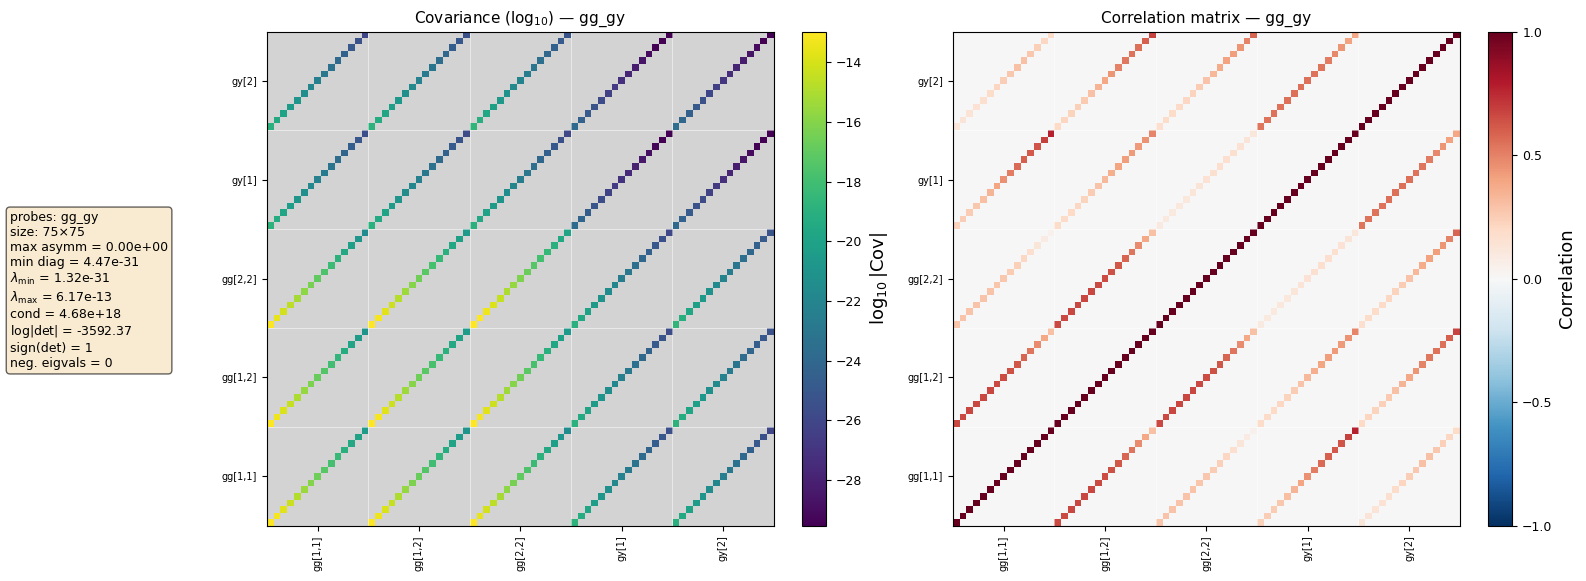

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gg_gy.png

Probes: ['gg', 'ky']   [gg_ky]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))
    03: ('ky', (1, 0))
    04: ('ky', (2, 0))

  Matrix size : (75, 75)
  Max asymm.  : 0.000e+00
  Min diag    : 7.914e-33
  Max diag    : 4.611e-13
  Eigen min   : 5.581e-33
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 75
  Condition # : 1.106e+20
  log|det|    : -3779.574  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


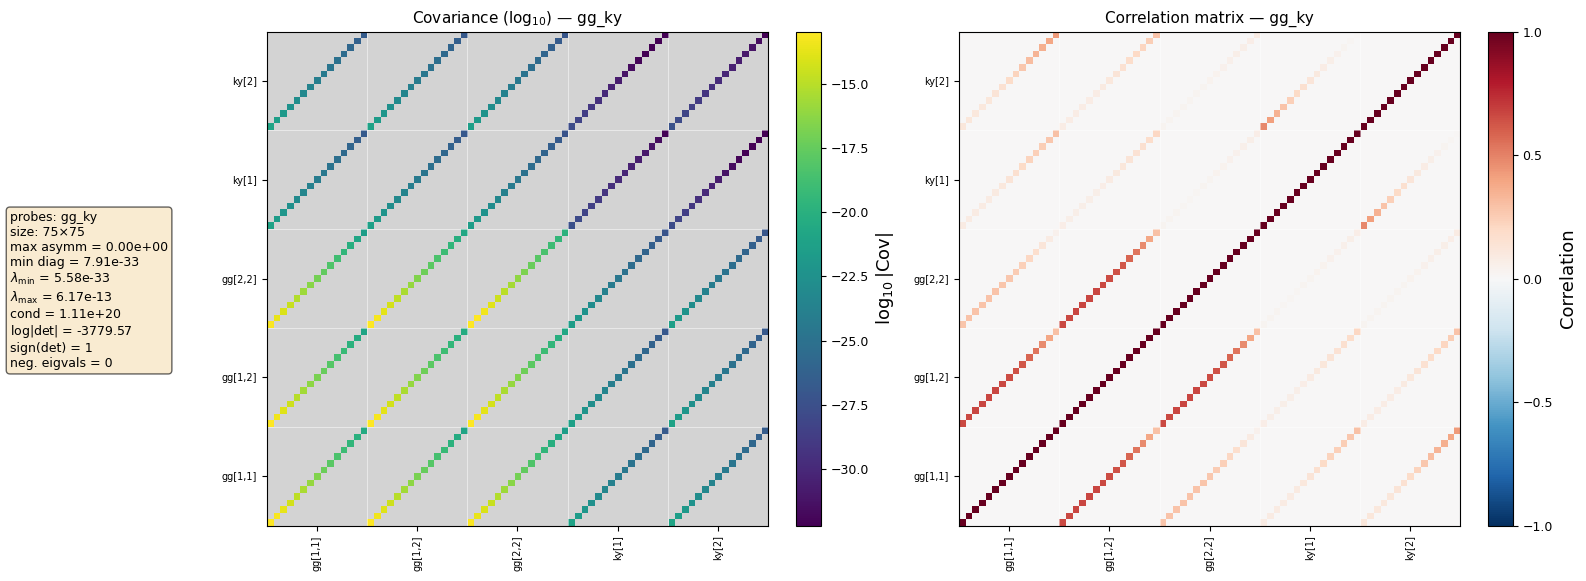

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gg_ky.png

Probes: ['yy', 'gg']   [yy_gg]
  yy bin_combs: [[0, 0]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('yy', (0, 0))
    01: ('gg', (1, 1))
    02: ('gg', (1, 2))
    03: ('gg', (2, 2))

  Matrix size : (60, 60)
  Max asymm.  : 0.000e+00
  Min diag    : 7.627e-41
  Max diag    : 4.611e-13
  Eigen min   : -1.161e-28
  Eigen max   : 6.173e-13
  Neg eigvals : 8 / 60
  Condition # : 9.097e+22
  log|det|    : -3000.519  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


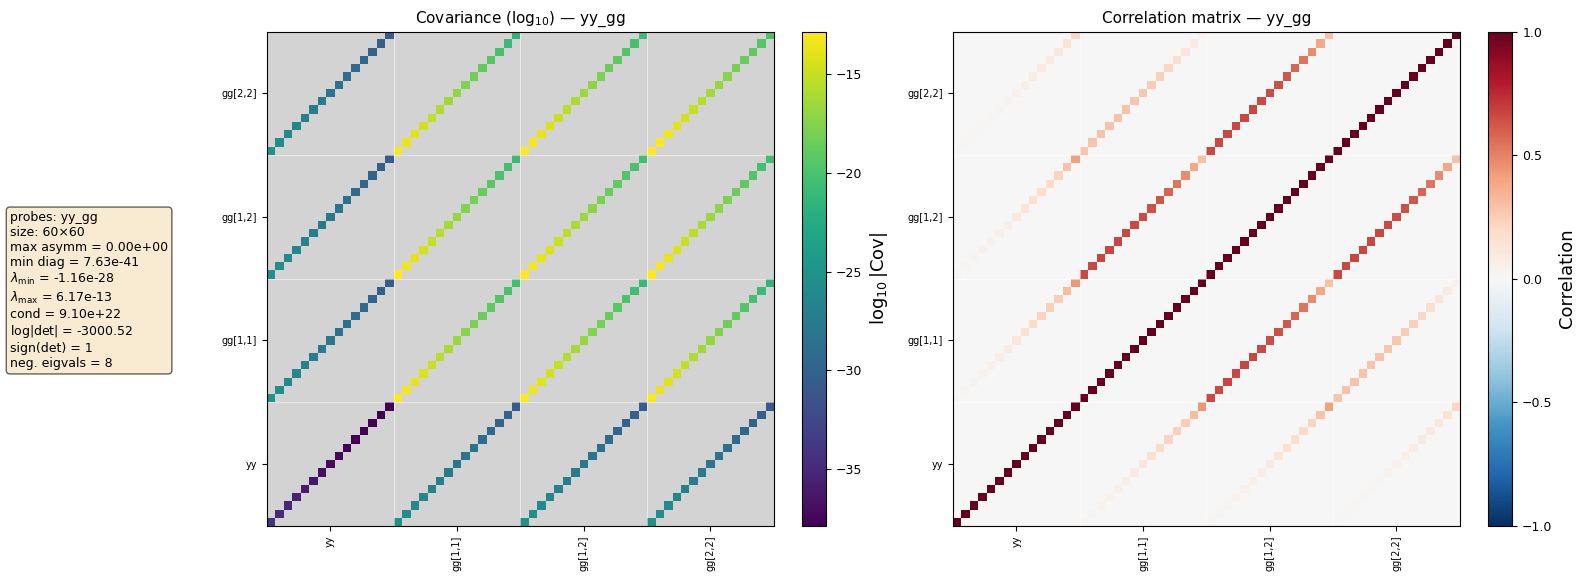

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_yy_gg.png

Probes: ['gy', 'gk']   [gy_gk]
  gy bin_combs: [[1, 0], [2, 0]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gy', (1, 0))
    01: ('gy', (2, 0))
    02: ('gk', (1, 1))
    03: ('gk', (1, 2))
    04: ('gk', (2, 1))
    05: ('gk', (2, 2))

  Matrix size : (90, 90)
  Max asymm.  : 0.000e+00
  Min diag    : 4.469e-31
  Max diag    : 3.875e-17
  Eigen min   : 3.027e-31
  Eigen max   : 7.371e-17
  Neg eigvals : 0 / 90
  Condition # : 2.431e+14
  log|det|    : -4550.753  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


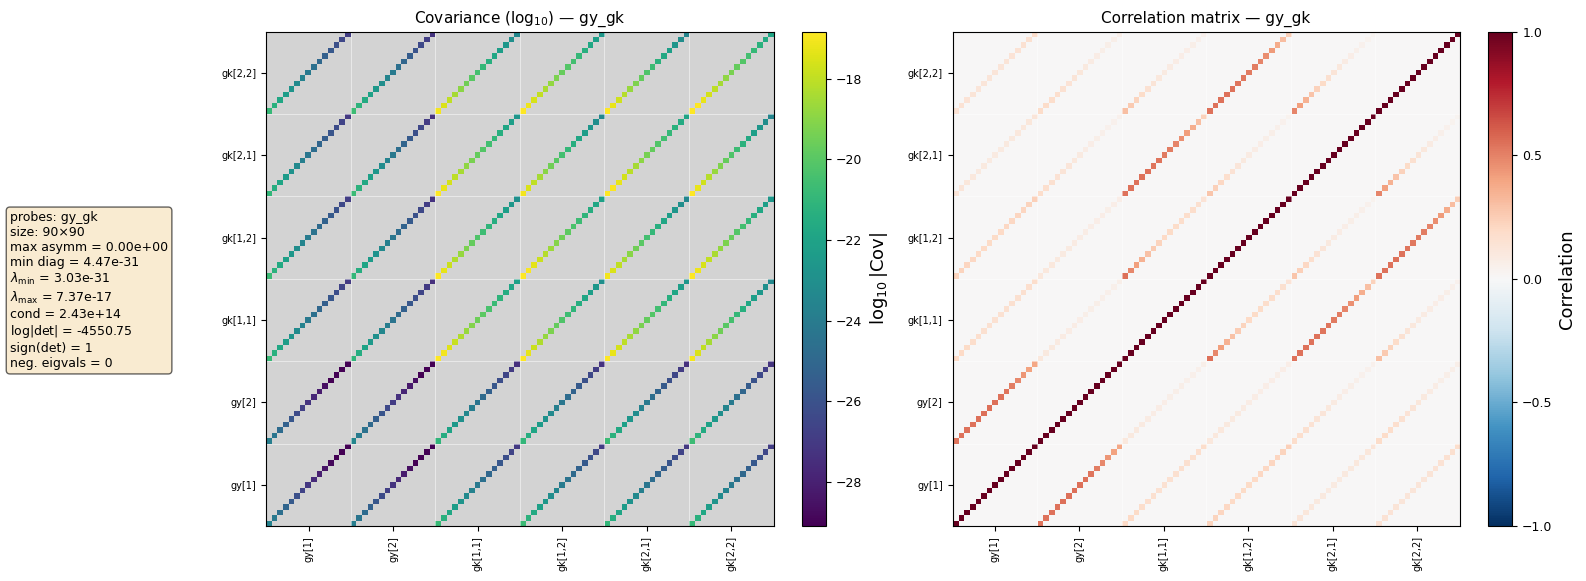

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gy_gk.png

Probes: ['gg', 'ky']   [gg_ky]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))
    03: ('ky', (1, 0))
    04: ('ky', (2, 0))

  Matrix size : (75, 75)
  Max asymm.  : 0.000e+00
  Min diag    : 7.914e-33
  Max diag    : 4.611e-13
  Eigen min   : 5.581e-33
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 75
  Condition # : 1.106e+20
  log|det|    : -3779.574  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


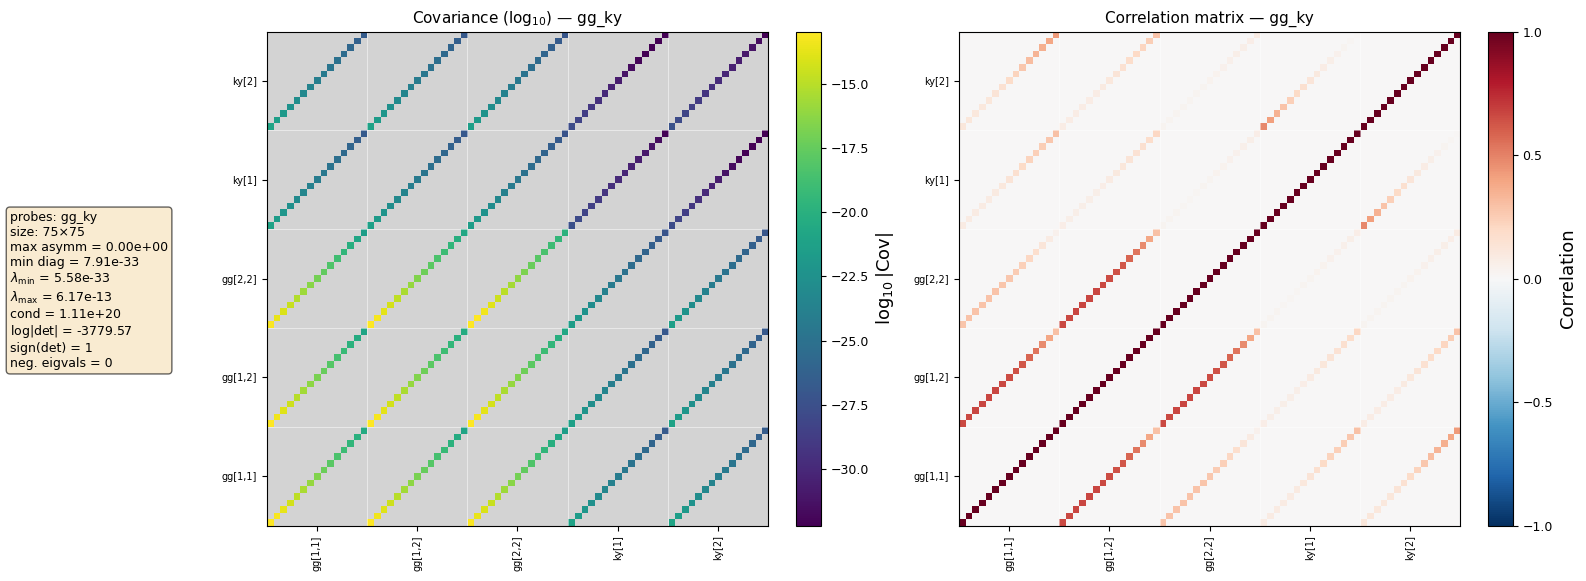

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gg_ky.png

Probes: ['gk', 'ky']   [gk_ky]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gk', (1, 1))
    01: ('gk', (1, 2))
    02: ('gk', (2, 1))
    03: ('gk', (2, 2))
    04: ('ky', (1, 0))
    05: ('ky', (2, 0))

  Matrix size : (90, 90)
  Max asymm.  : 0.000e+00
  Min diag    : 7.914e-33
  Max diag    : 3.875e-17
  Eigen min   : 3.630e-33
  Eigen max   : 7.371e-17
  Neg eigvals : 0 / 90
  Condition # : 2.030e+16
  log|det|    : -4748.841  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


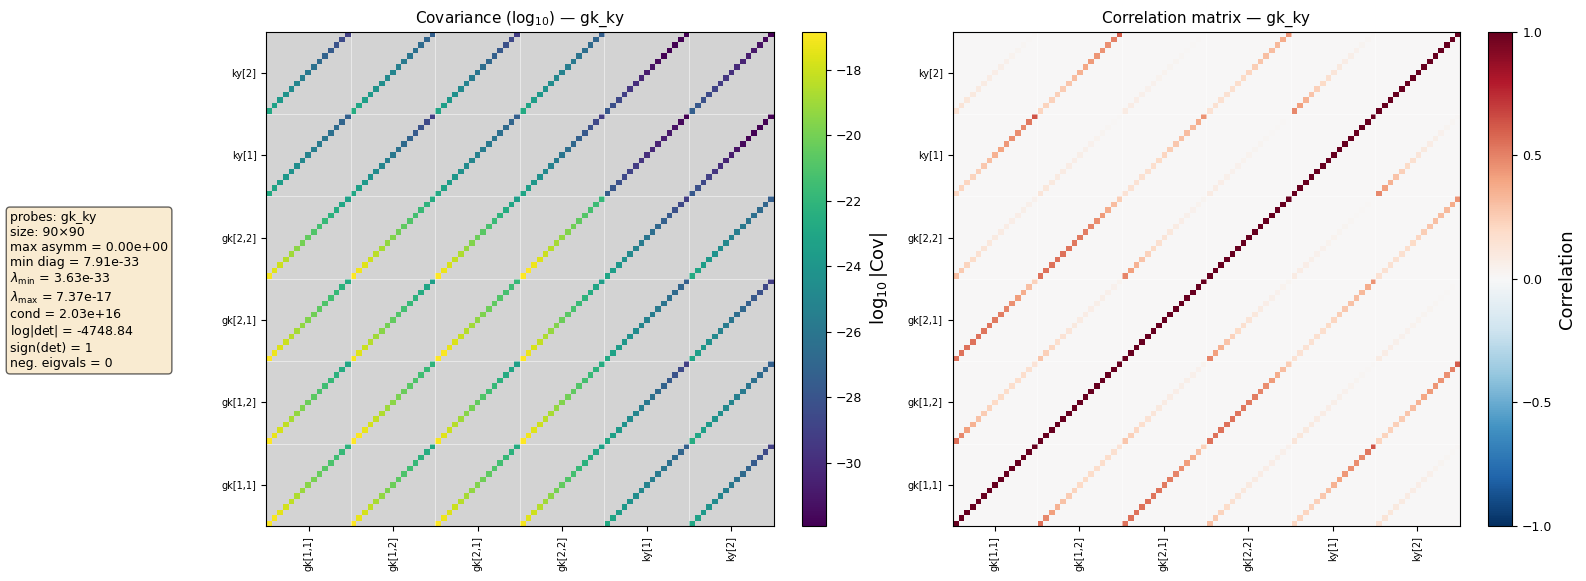

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gk_ky.png

Probes: ['gy', 'ky']   [gy_ky]
  gy bin_combs: [[1, 0], [2, 0]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gy', (1, 0))
    01: ('gy', (2, 0))
    02: ('ky', (1, 0))
    03: ('ky', (2, 0))

  Matrix size : (60, 60)
  Max asymm.  : 0.000e+00
  Min diag    : 7.914e-33
  Max diag    : 3.244e-24
  Eigen min   : 6.246e-33
  Eigen max   : 4.249e-24
  Neg eigvals : 0 / 60
  Condition # : 6.803e+08
  log|det|    : -3926.181  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


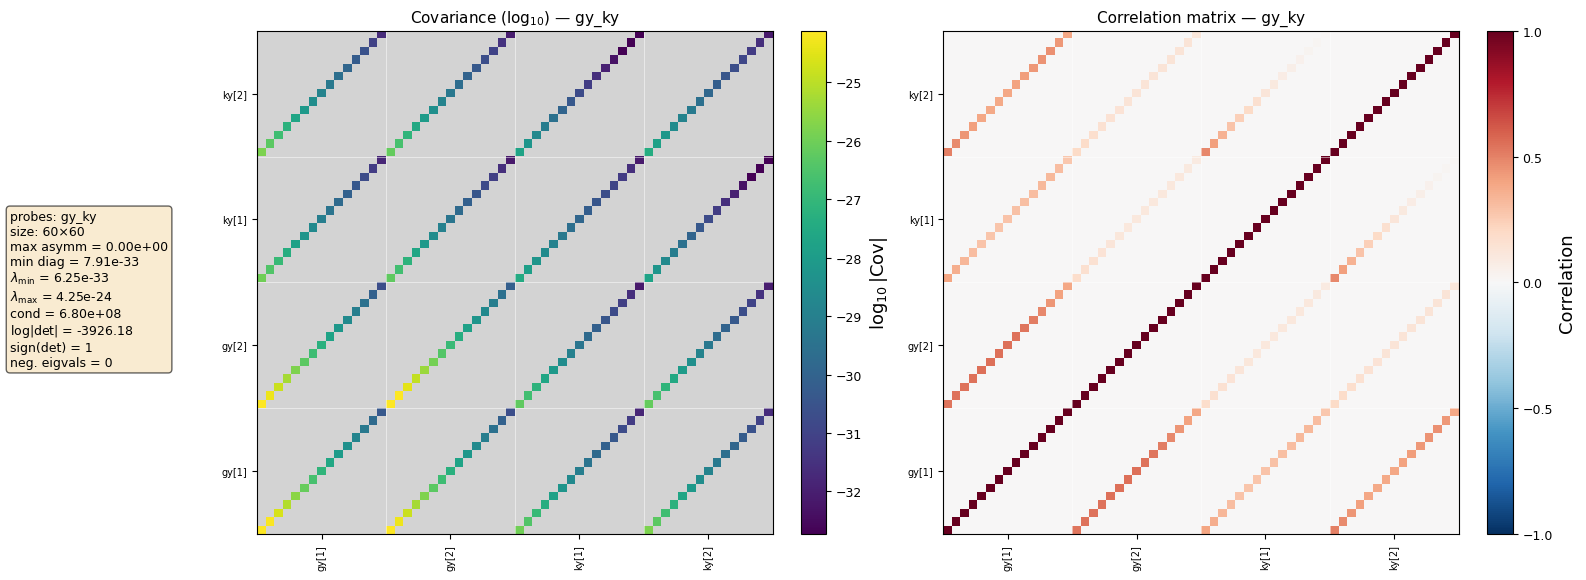

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_gy_ky.png

Probes: ['kk', 'gg', 'gk']   [kk_gg_gk]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))
    06: ('gk', (1, 1))
    07: ('gk', (1, 2))
    08: ('gk', (2, 1))
    09: ('gk', (2, 2))

  Matrix size : (150, 150)
  Max asymm.  : 0.000e+00
  Min diag    : 3.262e-24
  Max diag    : 4.611e-13
  Eigen min   : 2.684e-24
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 150
  Condition # : 2.300e+11
  log|det|    : -6684.623  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


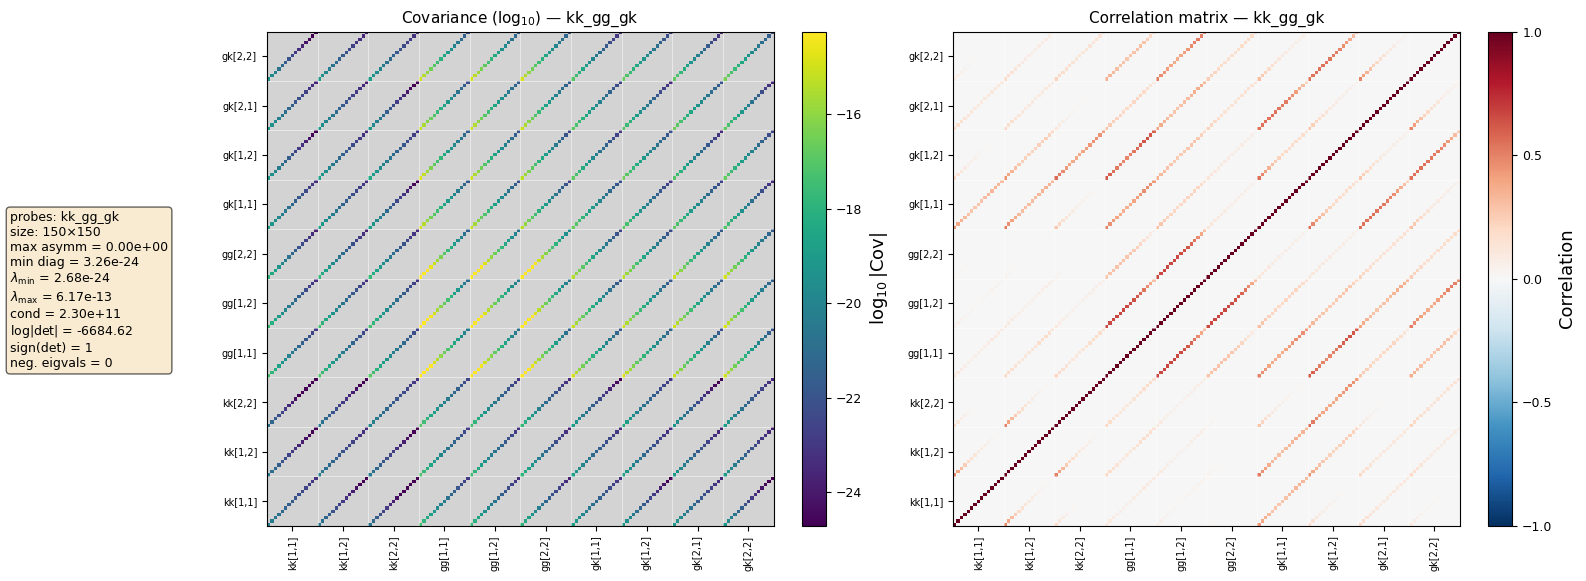

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_kk_gg_gk.png

Probes: ['kk', 'gg', 'gk', 'gy']   [kk_gg_gk_gy]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gy bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))
    06: ('gk', (1, 1))
    07: ('gk', (1, 2))
    08: ('gk', (2, 1))
    09: ('gk', (2, 2))
    10: ('gy', (1, 0))
    11: ('gy', (2, 0))

  Matrix size : (180, 180)
  Max asymm.  : 0.000e+00
  Min diag    : 4.469e-31
  Max diag    : 4.611e-13
  Eigen min   : 7.717e-32
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 180
  Condition # : 8.000e+18
  log|det|    : -8559.411  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


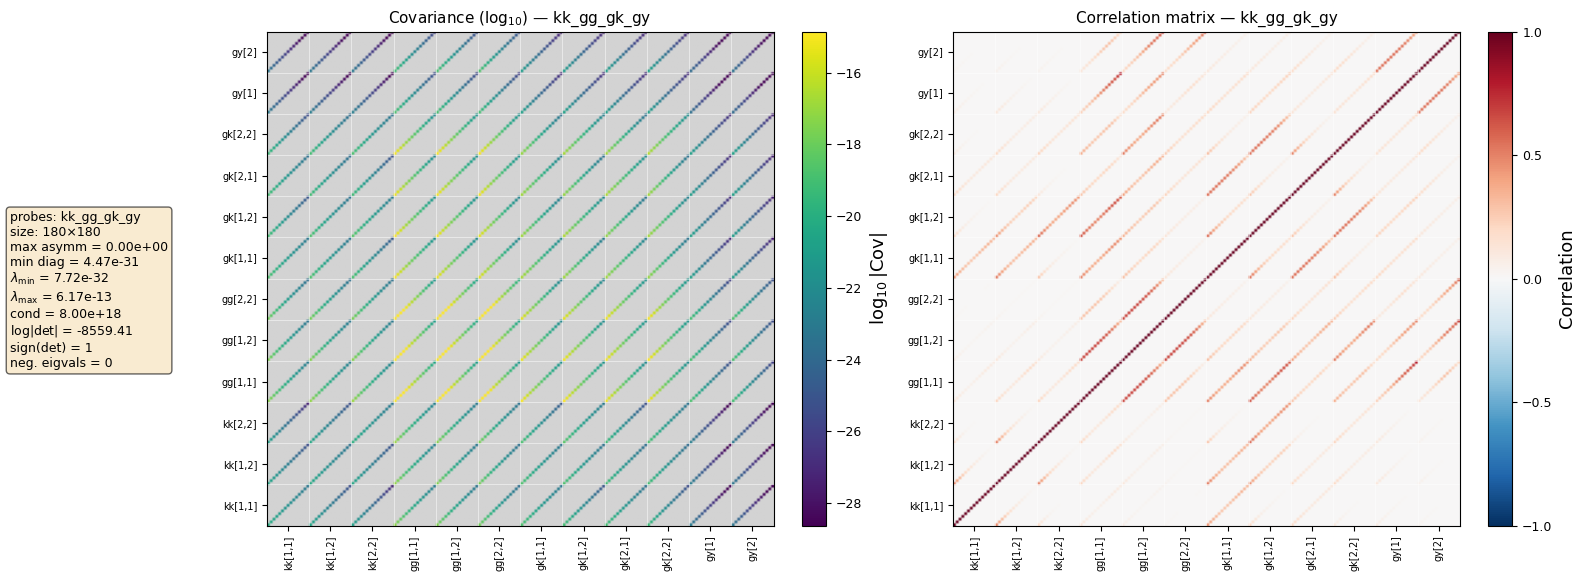

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_kk_gg_gk_gy.png

Probes: ['kk', 'gg', 'gk', 'ky']   [kk_gg_gk_ky]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))
    06: ('gk', (1, 1))
    07: ('gk', (1, 2))
    08: ('gk', (2, 1))
    09: ('gk', (2, 2))
    10: ('ky', (1, 0))
    11: ('ky', (2, 0))

  Matrix size : (180, 180)
  Max asymm.  : 0.000e+00
  Min diag    : 7.914e-33
  Max diag    : 4.611e-13
  Eigen min   : 3.004e-33
  Eigen max   : 6.173e-13
  Neg eigvals : 0 / 180
  Condition # : 2.055e+20
  log|det|    : -8749.215  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


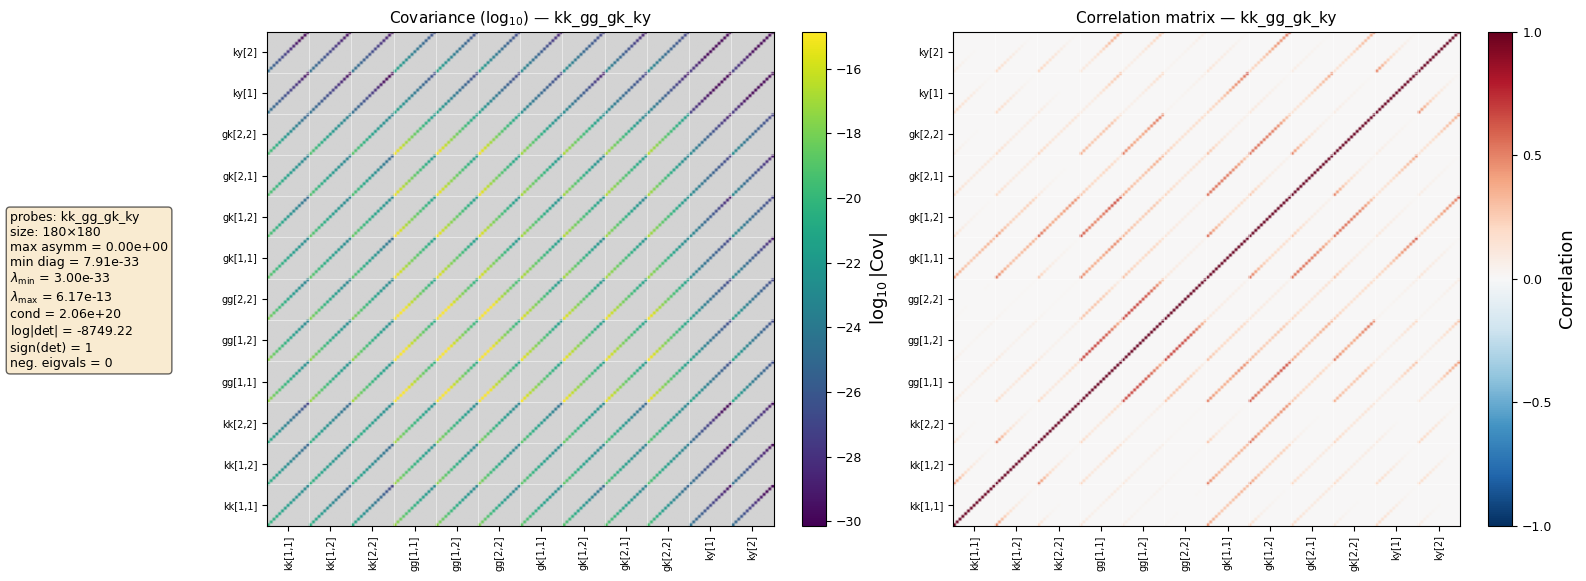

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_kk_gg_gk_ky.png

Probes: ['ky', 'kk', 'gg', 'gy', 'gk', 'yy']   [ky_kk_gg_gy_gk_yy]
  ky bin_combs: [[1, 0], [2, 0]]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gy bin_combs: [[1, 0], [2, 0]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  yy bin_combs: [[0, 0]]

  Full ordering:
    00: ('ky', (1, 0))
    01: ('ky', (2, 0))
    02: ('kk', (1, 1))
    03: ('kk', (1, 2))
    04: ('kk', (2, 2))
    05: ('gg', (1, 1))
    06: ('gg', (1, 2))
    07: ('gg', (2, 2))
    08: ('gy', (1, 0))
    09: ('gy', (2, 0))
    10: ('gk', (1, 1))
    11: ('gk', (1, 2))
    12: ('gk', (2, 1))
    13: ('gk', (2, 2))
    14: ('yy', (0, 0))

  Matrix size : (225, 225)
  Max asymm.  : 0.000e+00
  Min diag    : 7.627e-41
  Max diag    : 4.611e-13
  Eigen min   : -9.517e-29
  Eigen max   : 6.173e-13
  Neg eigvals : 7 / 225
  Condition # : 5.388e+28
  log|det|    : 

/tmp/ipykernel_1215154/338354171.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


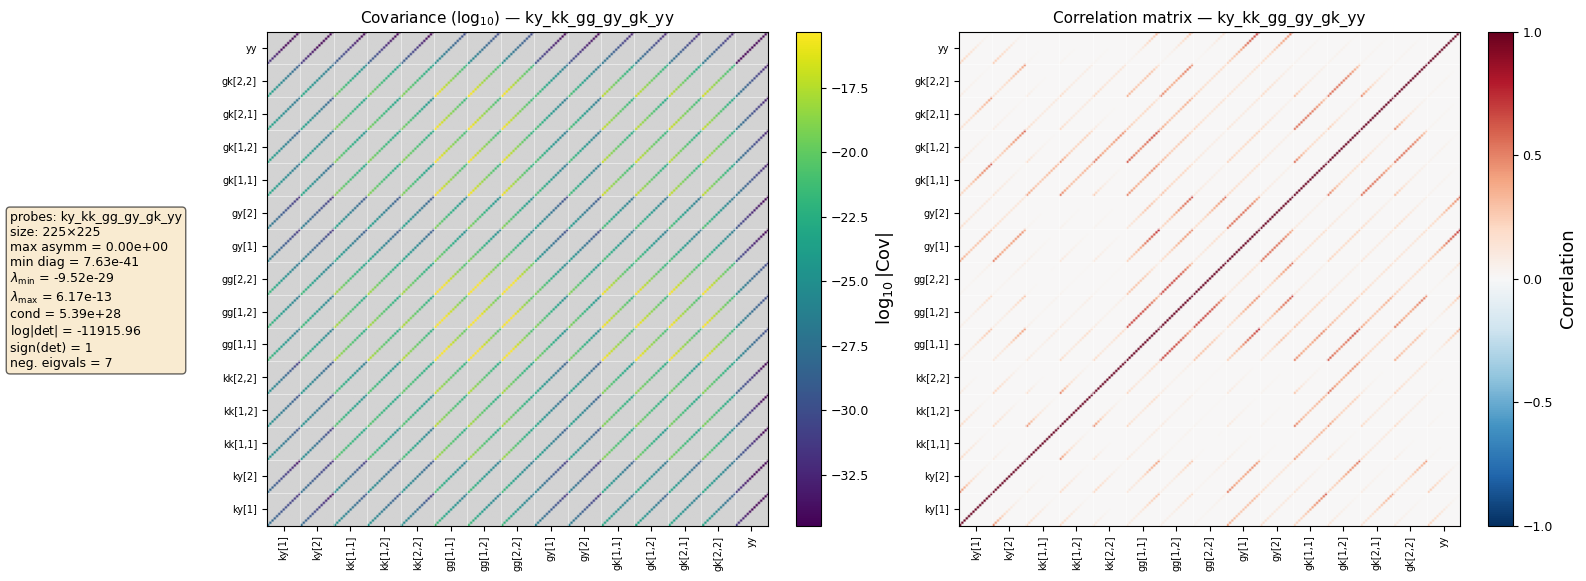

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/cov_corr_ky_kk_gg_gy_gk_yy.png


In [58]:
abs_path_results = '/home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/test_fix/'
# # Single probe 
# res_kk = analyze_covariance(["kk"], cov_fixed, analysis_dict, abs_path_results) 
# res_gg = analyze_covariance(["gg"], cov_fixed, analysis_dict, abs_path_results) 
# res_yy = analyze_covariance(["yy"], cov_fixed, analysis_dict, abs_path_results) 
# res_gy = analyze_covariance(["gy"], cov_fixed, analysis_dict, abs_path_results) 
# res_ky = analyze_covariance(["ky"], cov_fixed, analysis_dict, abs_path_results) 
# res_gk = analyze_covariance(["gk"], cov_fixed, analysis_dict, abs_path_results) 

# # Cross-probe subsets 
# res_kk_gk = analyze_covariance(["kk", "gk"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gy = analyze_covariance(["kk", "gy"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_ky = analyze_covariance(["kk", "ky"], cov_fixed, analysis_dict, abs_path_results)  
# res_kk_gg = analyze_covariance(["kk", "gg"], cov_fixed, analysis_dict, abs_path_results)
# res_kk_yy = analyze_covariance(["kk", "yy"], cov_fixed, analysis_dict, abs_path_results)

res_gk_gg = analyze_covariance(["gk", "gg"], cov_fixed, analysis_dict, abs_path_results) 
res_gg_gy = analyze_covariance(["gg", "gy"], cov_fixed, analysis_dict, abs_path_results) 
res_gg_ky = analyze_covariance(["gg", "ky"], cov_fixed, analysis_dict, abs_path_results) 
res_yy_gg = analyze_covariance(["yy", "gg"], cov_fixed, analysis_dict, abs_path_results)

res_gy_gk = analyze_covariance(["gy", "gk"], cov_fixed, analysis_dict, abs_path_results)
res_gg_ky = analyze_covariance(["gg", "ky"], cov_fixed, analysis_dict, abs_path_results) 
res_gk_ky = analyze_covariance(["gk", "ky"], cov_fixed, analysis_dict, abs_path_results) 
res_gy_ky = analyze_covariance(["gy", "ky"], cov_fixed, analysis_dict, abs_path_results) 

res_3x2 = analyze_covariance(["kk", "gg", "gk"], cov_fixed, analysis_dict, abs_path_results) 

res_kk_gg_gk_gy = analyze_covariance(["kk", "gg", "gk", "gy"], cov_fixed, analysis_dict, abs_path_results) 
res_kk_gg_gk_ky = analyze_covariance(["kk", "gg", "gk", "ky"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gg_gk_yy = analyze_covariance(["kk", "gg", "gk", "yy"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gg_gk_gy = analyze_covariance(["kk", "gg", "gk", "gy"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gg_gk_ky = analyze_covariance(["kk", "gg", "gk", "ky"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gg_gk_yy = analyze_covariance(["kk", "gg", "gk", "yy"], cov_fixed, analysis_dict, abs_path_results) 

# res_kk_gg_gk_gy_ky = analyze_covariance(["kk", "gg", "gk", "gy", "ky"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gg_gk_gy_yy = analyze_covariance(["kk", "gg", "gk", "gy", "yy"], cov_fixed, analysis_dict, abs_path_results) 
# res_kk_gg_gk_ky_yy = analyze_covariance(["kk", "gg", "gk", "ky", "yy"], cov_fixed, analysis_dict, abs_path_results) 

# #Full set 
res_all = analyze_covariance(["ky", "kk", "gg", "gy", "gk", "yy"], cov_fixed, analysis_dict, abs_path_results)